In [1]:
import pandas as pd
import numpy as np
from statics import *
import seaborn as sns
import matplotlib.pyplot as plt
# https://data.crunchbase.com/docs/data-dictionary

In [2]:
pd.set_option('display.max_columns', None)  # Show all columns when displaying DataFrames

In [3]:
# load raw data
org_df_raw = pd.read_csv('20251012_bulk_export/organizations.csv')
org_des_df_raw = pd.read_csv('20251012_bulk_export/organization_descriptions.csv')
fund_rounds_df_raw = pd.read_csv('20251012_bulk_export/funding_rounds.csv')

# narrow down the scope
- North America (CAN + USA)
- Company roles: please keep only “company” and “company,investor”  (I.e., exclude “school”, “investor”, “school,company”, etc.)
- Founding date (founded_on) 2005 or later (if missing, you can keep the observation for now)
- If company “status” is closed: closing date (closed_on) 2019 or late

In [4]:
org_df = org_df_raw[org_df_raw['country_code'].isin(['USA', 'CAN'])]  # filter to US and Canada only
org_df = org_df[org_df['roles'].isin(['company', 'company,investor'])]  # filter to keep only organizations that are not investors
# fileter on founded_on >=2005-01-01
org_df['founded_on'] = pd.to_datetime(org_df['founded_on'], errors='coerce')
org_df = org_df[org_df['founded_on'] >= '2005-01-01']
# exclude companies with  status 'closed' and close_on before 2019-01-01
org_df['close_on'] = pd.to_datetime(org_df['closed_on'], errors='coerce')
org_df = org_df[~((org_df['status'] == 'closed') & (org_df['close_on'] < '2019-01-01'))]

# add description info 
org_df = pd.merge(org_des_df_raw[['uuid','description']], org_df, on='uuid',how='right')


In [5]:
org_df['status'].value_counts()

status
operating    616930
closed        38430
acquired      23225
ipo            4091
Name: count, dtype: int64

In [6]:
cats = org_df['category_list']
cats_exploded = cats.str.split(',').explode().str.strip()
all_categories = cats_exploded.dropna().unique()
len(all_categories)

798

# Add fund rouds info
- Is vc funds
- Startups that are private but have not raised a funding round (or recorded any other event) in 5 years can be coded as “inactive”
- Add age of companies

In [7]:
print(f"Number of organizations after filtering: {org_df['uuid'].nunique()}")
# Add fund rouds info
print(f"Number of funding rounds before filtering: {fund_rounds_df_raw['org_uuid'].nunique()}")


Number of organizations after filtering: 682676
Number of funding rounds before filtering: 382591


In [8]:
fund_rounds_df = fund_rounds_df_raw[['uuid', 'org_uuid', 'name', 'investment_type', 'announced_on', 'raised_amount_usd']].copy()
fund_rounds_df.columns = [f"FR_{c}" for c in fund_rounds_df.columns]

# join org_df with fund_rounds_df_raw on 'uuid' and 'organization_uuid', # TODO companies without funding??????
df_org_fund = pd.merge(org_df, fund_rounds_df, left_on='uuid', right_on='FR_org_uuid', how='inner')

# exclude all organizations where the first funding round of any type was before 2005
df_org_fund['FR_announced_on'] = pd.to_datetime(df_org_fund['FR_announced_on'], errors='coerce')

df_org_fund = df_org_fund.sort_values('FR_announced_on')
first_funding = df_org_fund.groupby('uuid')['FR_announced_on'].min().reset_index()
drop_orgs = first_funding[first_funding['FR_announced_on'] < '2005-01-01']['uuid'].unique()
# filter org_df (keep orgs with no funding record or first funding >= 2005)
df_org_fund = df_org_fund[~df_org_fund['uuid'].isin(drop_orgs)]

# for private companies, if last funding round is more than 5 years ago, code as inactive
df_org_fund['FR_announced_on'] = pd.to_datetime(df_org_fund['FR_announced_on'], errors='coerce')
last_funding = df_org_fund[df_org_fund['status']=='operating'].groupby('uuid')['FR_announced_on'].max().reset_index()
last_funding['is_inactive'] = (last_funding['FR_announced_on'] < pd.Timestamp.now() - pd.DateOffset(years=5)).astype(int)
df_org_fund = pd.merge(df_org_fund, last_funding[['uuid', 'is_inactive']], on='uuid', how='left')


df_org_fund['is_vc_funded'] = df_org_fund['FR_investment_type'].isin(VC_FUND_TYPES).astype(int)

# add age of companies based on founded_on date and current date
df_org_fund['founded_on'] = pd.to_datetime(df_org_fund['founded_on'], errors='coerce')
df_org_fund['company_age'] = ((pd.Timestamp.now() - df_org_fund['founded_on']).dt.days / 365).astype(int)

In [9]:
org_df_raw.columns

Index(['uuid', 'name', 'type', 'permalink', 'cb_url', 'rank', 'created_at',
       'updated_at', 'legal_name', 'roles', 'domain', 'homepage_url',
       'country_code', 'state_code', 'region', 'city', 'address',
       'postal_code', 'status', 'short_description', 'category_list',
       'category_groups_list', 'num_funding_rounds', 'total_funding_usd',
       'total_funding', 'total_funding_currency_code', 'founded_on',
       'last_funding_on', 'closed_on', 'employee_count', 'email', 'phone',
       'facebook_url', 'linkedin_url', 'twitter_url', 'logo_url', 'alias1',
       'alias2', 'alias3', 'primary_role', 'num_exits'],
      dtype='object')

In [10]:
df_org_fund.head()

,uuid,description,name,type,permalink,cb_url,rank,created_at,updated_at,legal_name,roles,domain,homepage_url,country_code,state_code,region,city,address,postal_code,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,total_funding_currency_code,founded_on,last_funding_on,closed_on,employee_count,email,phone,facebook_url,linkedin_url,twitter_url,logo_url,alias1,alias2,alias3,primary_role,num_exits,close_on,FR_uuid,FR_org_uuid,FR_name,FR_investment_type,FR_announced_on,FR_raised_amount_usd,is_inactive,is_vc_funded,company_age
0,0954d5cd-96d1-9017-901a-0b28284f06f7,Reddit is an online platform that enables user...,Reddit,organization,reddit,https://www.crunchbase.com/organization/reddit,1843.0,2007-07-31 11:41:41,2025-09-26 03:54:36,"Reddit, Inc.","company,investor",redditinc.com,https://www.redditinc.com,USA,CA,California,San Francisco,520 3rd St,94107,acquired,Reddit is an online platform that enables user...,"Content,News,Social Media,Social Network","Content and Publishing,Internet Services,Media...",9.0,1.329050e+09,1.329050e+09,USD,2005-01-01,2021-08-12,NaN,1001-5000,contact@reddit.com,NaN,http://www.facebook.com/reddit,https://www.linkedin.com/company/reddit-com,http://www.twitter.com/reddit,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,1.0,NaT,efe1e2d6-1370-4af0-832d-65550af2e78a,0954d5cd-96d1-9017-901a-0b28284f06f7,Seed Round - Reddit,seed,2005-01-01,NaN,NaN,1,20
1,908247bf-9e4b-3810-9857-33beffd704ea,Brownbag is a customer-centric destination for...,Brownbag,organization,nowpublic,https://www.crunchbase.com/organization/nowpublic,3195757.0,2007-07-27 16:05:04,2022-07-18 12:50:05,NaN,company,brownbag.in,https://brownbag.in/,CAN,BC,British Columbia,Vancouver,576 Seymour Street Suite 204,NaN,closed,Brownbag is a customer-centric destination for...,"Crowdsourcing,News,Social News","Content and Publishing,Media and Entertainment...",3.0,1.200000e+07,1.200000e+07,USD,2005-01-01,2007-07-01,NaN,1-10,info@nowpublic.com,8383020890,https://www.facebook.com/BrownbagGrocery/,NaN,http://twitter.com/NowPublic,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,651885e0-1582-73c0-8074-618824d387a2,908247bf-9e4b-3810-9857-33beffd704ea,Seed Round - Brownbag,seed,2005-01-01,NaN,NaN,1,20
2,e7920489-0fe9-c9d8-9681-d84367861532,"Zmanda, Inc. provides cloud backup and open so...",Zmanda,organization,zmanda,https://www.crunchbase.com/organization/zmanda,447197.0,2008-08-16 03:46:54,2024-06-12 17:45:24,Zmanda Inc,company,zmanda.com,http://www.zmanda.com,USA,CA,California,Sunnyvale,465 S. Mathilda Ave Suite 300,94086,acquired,ZManda is an open source and cloud backup soft...,"Cloud Computing,Open Source,Software","Internet Services,Software",2.0,1.300000e+07,1.300000e+07,USD,2005-01-01,2007-05-22,NaN,51-100,info@zmanda.com,408-732-3208,https://www.facebook.com/zmandainc,https://www.linkedin.com/company/zmanda,http://twitter.com/zmanda,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,8bb15f68-2b46-27ab-512b-81e9a5b40426,e7920489-0fe9-c9d8-9681-d84367861532,Series A - Zmanda,series_a,2005-01-01,5000000.0,NaN,1,20
3,b713d2b2-1581-399d-98fa-af2f048df5cc,Allurent work on online shopping experiences t...,Allurent,organization,allurent,https://www.crunchbase.com/organization/allurent,405679.0,2010-02-24 10:46:14,2025-08-20 10:53:08,Allurent,company,allurent.com,http://www.allurent.com,USA,MA,Massachusetts,Cambridge,222 Third Street 4th Floor,02142,closed,Allurent is a hosted SaaS-based solution provi...,"E-Commerce,Enterprise Software,Internet,Intern...","Commerce and Shopping,Internet Services,Software",4.0,9.500000e+06,9.500000e+06,USD,2005-01-01,2010-02-22,NaN,11-50,info@allurent.com,(617)374-8800,http://www.facebook.com/Allurent-On-Demand/165...,https://www.linkedin.com/company/profitlogic,http://twitter.com/allurent,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,87669a31-61e4-451d-

In [11]:
df_org_fund['is_inactive'].value_counts()

is_inactive
0.0    135599
1.0     62548
Name: count, dtype: int64

In [12]:
df_org_fund['is_vc_funded'].value_counts()

is_vc_funded
1    199252
0     68810
Name: count, dtype: int64

In [13]:
df_org_fund.head()

,uuid,description,name,type,permalink,cb_url,rank,created_at,updated_at,legal_name,roles,domain,homepage_url,country_code,state_code,region,city,address,postal_code,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,total_funding_currency_code,founded_on,last_funding_on,closed_on,employee_count,email,phone,facebook_url,linkedin_url,twitter_url,logo_url,alias1,alias2,alias3,primary_role,num_exits,close_on,FR_uuid,FR_org_uuid,FR_name,FR_investment_type,FR_announced_on,FR_raised_amount_usd,is_inactive,is_vc_funded,company_age
0,0954d5cd-96d1-9017-901a-0b28284f06f7,Reddit is an online platform that enables user...,Reddit,organization,reddit,https://www.crunchbase.com/organization/reddit,1843.0,2007-07-31 11:41:41,2025-09-26 03:54:36,"Reddit, Inc.","company,investor",redditinc.com,https://www.redditinc.com,USA,CA,California,San Francisco,520 3rd St,94107,acquired,Reddit is an online platform that enables user...,"Content,News,Social Media,Social Network","Content and Publishing,Internet Services,Media...",9.0,1.329050e+09,1.329050e+09,USD,2005-01-01,2021-08-12,NaN,1001-5000,contact@reddit.com,NaN,http://www.facebook.com/reddit,https://www.linkedin.com/company/reddit-com,http://www.twitter.com/reddit,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,1.0,NaT,efe1e2d6-1370-4af0-832d-65550af2e78a,0954d5cd-96d1-9017-901a-0b28284f06f7,Seed Round - Reddit,seed,2005-01-01,NaN,NaN,1,20
1,908247bf-9e4b-3810-9857-33beffd704ea,Brownbag is a customer-centric destination for...,Brownbag,organization,nowpublic,https://www.crunchbase.com/organization/nowpublic,3195757.0,2007-07-27 16:05:04,2022-07-18 12:50:05,NaN,company,brownbag.in,https://brownbag.in/,CAN,BC,British Columbia,Vancouver,576 Seymour Street Suite 204,NaN,closed,Brownbag is a customer-centric destination for...,"Crowdsourcing,News,Social News","Content and Publishing,Media and Entertainment...",3.0,1.200000e+07,1.200000e+07,USD,2005-01-01,2007-07-01,NaN,1-10,info@nowpublic.com,8383020890,https://www.facebook.com/BrownbagGrocery/,NaN,http://twitter.com/NowPublic,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,651885e0-1582-73c0-8074-618824d387a2,908247bf-9e4b-3810-9857-33beffd704ea,Seed Round - Brownbag,seed,2005-01-01,NaN,NaN,1,20
2,e7920489-0fe9-c9d8-9681-d84367861532,"Zmanda, Inc. provides cloud backup and open so...",Zmanda,organization,zmanda,https://www.crunchbase.com/organization/zmanda,447197.0,2008-08-16 03:46:54,2024-06-12 17:45:24,Zmanda Inc,company,zmanda.com,http://www.zmanda.com,USA,CA,California,Sunnyvale,465 S. Mathilda Ave Suite 300,94086,acquired,ZManda is an open source and cloud backup soft...,"Cloud Computing,Open Source,Software","Internet Services,Software",2.0,1.300000e+07,1.300000e+07,USD,2005-01-01,2007-05-22,NaN,51-100,info@zmanda.com,408-732-3208,https://www.facebook.com/zmandainc,https://www.linkedin.com/company/zmanda,http://twitter.com/zmanda,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,8bb15f68-2b46-27ab-512b-81e9a5b40426,e7920489-0fe9-c9d8-9681-d84367861532,Series A - Zmanda,series_a,2005-01-01,5000000.0,NaN,1,20
3,b713d2b2-1581-399d-98fa-af2f048df5cc,Allurent work on online shopping experiences t...,Allurent,organization,allurent,https://www.crunchbase.com/organization/allurent,405679.0,2010-02-24 10:46:14,2025-08-20 10:53:08,Allurent,company,allurent.com,http://www.allurent.com,USA,MA,Massachusetts,Cambridge,222 Third Street 4th Floor,02142,closed,Allurent is a hosted SaaS-based solution provi...,"E-Commerce,Enterprise Software,Internet,Intern...","Commerce and Shopping,Internet Services,Software",4.0,9.500000e+06,9.500000e+06,USD,2005-01-01,2010-02-22,NaN,11-50,info@allurent.com,(617)374-8800,http://www.facebook.com/Allurent-On-Demand/165...,https://www.linkedin.com/company/profitlogic,http://twitter.com/allurent,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,87669a31-61e4-451d-

# Apply key words identification of platform and non platform
- baded on category list 
- based on description

### Distinguish non-platform businesses between:   
-“Digital” companies (software)   
-“Non-digital” companies: robotics, industrials, hardware, consumer staples, biotech, pharmaceuticals – anything physical   
-(So, there will be two “control groups”. Don’t worry if this distinction is very imperfect – even something approximate will be fine.)

In [14]:
df_org_fund['num_category_platform'] = df_org_fund['category_list'].apply(
    lambda x: sum(1 for cat in platform_categories if cat in x.split(',')) if pd.notna(x) else 0)


In [15]:
df_org_fund['num_category_nonplatform'] = df_org_fund['category_list'].apply(
    lambda x: sum(1 for cat in non_platform_categories if cat in x.split(',')) if pd.notna(x) else 0)


In [16]:
df_org_fund['num_keyword_platform'] = df_org_fund['description'].apply(
    lambda x: sum(1 for kw in platform_keywords if kw in x.lower()) if pd.notna(x) else 0
)
df_org_fund['num_keyword_nonplatform'] = df_org_fund['description'].apply(
    lambda x: sum(1 for kw in non_platform_keywords if kw in x.lower()) if pd.notna(x) else 0)

In [17]:
# df_org_fund['num_category_digital_nonplatform'] = df_org_fund['category_list'].apply(
#     lambda x: sum(1 for cat in digital_nonplatform_categories if cat in x.split(',')) if pd.notna(x) else 0)

# df_org_fund['num_category_nonditigal_nonplatform'] = df_org_fund['category_list'].apply(
#     lambda x: sum(1 for cat in nondigital_nonplatform_categories if cat in x.split(',')) if pd.notna(x) else 0)

df_org_fund['num_keyword_digital_nonplatform'] = df_org_fund['category_list'].apply(
    lambda x: sum(1 for kw in digital_nonplatform_keywords if kw in x.lower()) if pd.notna(x) else 0
)

df_org_fund['num_keyword_nonditigal_nonplatform'] = df_org_fund['category_list'].apply(
  lambda x: sum(1 for kw in nondigital_nonplatform_keywords if kw in x.lower()) if pd.notna(x) else 0
)



In [18]:
def check_platform_strict(row):
    if row['num_category_platform'] > row['num_category_nonplatform'] and row['num_keyword_platform'] > row['num_keyword_nonplatform']:
        return 1
    else:
        return 0

In [19]:
def check_platform_weak(row):
    if row['num_category_platform'] > row['num_category_nonplatform'] or row['num_keyword_platform'] > row['num_keyword_nonplatform']:
        return 1
    else:
        return 0

In [20]:
def check_platform_weak(row):
    if row['num_category_platform'] > row['num_category_nonplatform'] or row['num_keyword_platform'] > row['num_keyword_nonplatform']:
        return 1
    else:
        return 0

In [21]:
def check_digital_nonplatform(row):
    if not row['is_platform_strict']:
        if row['num_keyword_digital_nonplatform'] >= row['num_keyword_nonditigal_nonplatform']:
            return 1
        else:
            return 0
    else:
        return -1 

In [22]:
df_org_fund['is_platform_strict'] = df_org_fund.apply(lambda row: check_platform_strict(row), axis=1)
df_org_fund['is_platform_weak'] = df_org_fund.apply(lambda row: check_platform_weak(row), axis=1)

In [23]:
df_org_fund['is_digital_nonplatform'] = df_org_fund.apply(lambda row: check_digital_nonplatform(row), axis=1)

In [24]:
df_org_fund.head()

,uuid,description,name,type,permalink,cb_url,rank,created_at,updated_at,legal_name,roles,domain,homepage_url,country_code,state_code,region,city,address,postal_code,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,total_funding_currency_code,founded_on,last_funding_on,closed_on,employee_count,email,phone,facebook_url,linkedin_url,twitter_url,logo_url,alias1,alias2,alias3,primary_role,num_exits,close_on,FR_uuid,FR_org_uuid,FR_name,FR_investment_type,FR_announced_on,FR_raised_amount_usd,is_inactive,is_vc_funded,company_age,num_category_platform,num_category_nonplatform,num_keyword_platform,num_keyword_nonplatform,num_keyword_digital_nonplatform,num_keyword_nonditigal_nonplatform,is_platform_strict,is_platform_weak,is_digital_nonplatform
0,0954d5cd-96d1-9017-901a-0b28284f06f7,Reddit is an online platform that enables user...,Reddit,organization,reddit,https://www.crunchbase.com/organization/reddit,1843.0,2007-07-31 11:41:41,2025-09-26 03:54:36,"Reddit, Inc.","company,investor",redditinc.com,https://www.redditinc.com,USA,CA,California,San Francisco,520 3rd St,94107,acquired,Reddit is an online platform that enables user...,"Content,News,Social Media,Social Network","Content and Publishing,Internet Services,Media...",9.0,1.329050e+09,1.329050e+09,USD,2005-01-01,2021-08-12,NaN,1001-5000,contact@reddit.com,NaN,http://www.facebook.com/reddit,https://www.linkedin.com/company/reddit-com,http://www.twitter.com/reddit,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,1.0,NaT,efe1e2d6-1370-4af0-832d-65550af2e78a,0954d5cd-96d1-9017-901a-0b28284f06f7,Seed Round - Reddit,seed,2005-01-01,NaN,NaN,1,20,2,1,1,0,0,0,1,1,-1
1,908247bf-9e4b-3810-9857-33beffd704ea,Brownbag is a customer-centric destination for...,Brownbag,organization,nowpublic,https://www.crunchbase.com/organization/nowpublic,3195757.0,2007-07-27 16:05:04,2022-07-18 12:50:05,NaN,company,brownbag.in,https://brownbag.in/,CAN,BC,British Columbia,Vancouver,576 Seymour Street Suite 204,NaN,closed,Brownbag is a customer-centric destination for...,"Crowdsourcing,News,Social News","Content and Publishing,Media and Entertainment...",3.0,1.200000e+07,1.200000e+07,USD,2005-01-01,2007-07-01,NaN,1-10,info@nowpublic.com,8383020890,https://www.facebook.com/BrownbagGrocery/,NaN,http://twitter.com/NowPublic,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,651885e0-1582-73c0-8074-618824d387a2,908247bf-9e4b-3810-9857-33beffd704ea,Seed Round - Brownbag,seed,2005-01-01,NaN,NaN,1,20,2,1,3,0,0,0,1,1,-1
2,e7920489-0fe9-c9d8-9681-d84367861532,"Zmanda, Inc. provides cloud backup and open so...",Zmanda,organization,zmanda,https://www.crunchbase.com/organization/zmanda,447197.0,2008-08-16 03:46:54,2024-06-12 17:45:24,Zmanda Inc,company,zmanda.com,http://www.zmanda.com,USA,CA,California,Sunnyvale,465 S. Mathilda Ave Suite 300,94086,acquired,ZManda is an open source and cloud backup soft...,"Cloud Computing,Open Source,Software","Internet Services,Software",2.0,1.300000e+07,1.300000e+07,USD,2005-01-01,2007-05-22,NaN,51-100,info@zmanda.com,408-732-3208,https://www.facebook.com/zmandainc,https://www.linkedin.com/company/zmanda,http://twitter.com/zmanda,https://images.crunchbase.com/image/upload/t_c...,NaN,NaN,NaN,company,NaN,NaT,8bb15f68-2b46-27ab-512b-81e9a5b40426,e7920489-0fe9-c9d8-9681-d84367861532,Series A - Zmanda,series_a,2005-01-01,5000000.0,NaN,1,20,0,0,0,2,1,0,0,0,1
3,b713d2b2-1581-399d-98fa-af2f048df5cc,Allurent work on online shopping experiences t...,Allurent,organization,allurent,https://www.crunchbase.com/organization/allurent,405679.0,2010-02-24 10:46:14,2025-08-20 10:53:08,Allurent,company,allurent.com,http://www.allurent.com,USA,MA,Massachusetts,Cambridge,222 Third Street 4th Floor,02142,closed,Allurent is a hosted SaaS-based solution provi...,"E-Commerce,Enterprise Software,Internet,Intern...","Commerce and Shopping,Internet Services,Software",4.0,9.500000e+06,9.500000e+06,USD,2005-01-01

In [25]:
df_org_fund.columns

Index(['uuid', 'description', 'name', 'type', 'permalink', 'cb_url', 'rank',
       'created_at', 'updated_at', 'legal_name', 'roles', 'domain',
       'homepage_url', 'country_code', 'state_code', 'region', 'city',
       'address', 'postal_code', 'status', 'short_description',
       'category_list', 'category_groups_list', 'num_funding_rounds',
       'total_funding_usd', 'total_funding', 'total_funding_currency_code',
       'founded_on', 'last_funding_on', 'closed_on', 'employee_count', 'email',
       'phone', 'facebook_url', 'linkedin_url', 'twitter_url', 'logo_url',
       'alias1', 'alias2', 'alias3', 'primary_role', 'num_exits', 'close_on',
       'FR_uuid', 'FR_org_uuid', 'FR_name', 'FR_investment_type',
       'FR_announced_on', 'FR_raised_amount_usd', 'is_inactive',
       'is_vc_funded', 'company_age', 'num_category_platform',
       'num_category_nonplatform', 'num_keyword_platform',
       'num_keyword_nonplatform', 'num_keyword_digital_nonplatform',
       'num_keyword

In [26]:
df_org_grouped = df_org_fund.groupby('uuid', as_index=False).first()
df_org_grouped['first_round_on'] = df_org_grouped['FR_announced_on']
df_org_grouped.drop(columns=['FR_uuid', 'FR_org_uuid', 'FR_name', 'FR_investment_type', 'FR_announced_on', 'FR_raised_amount_usd'], inplace=True)

In [27]:
df_org_grouped['description']

0         Resilio is a digital well-being company, is co...
1         Greenheart Gold is a mining company that speci...
2         Codementor provides live 1:1 help for software...
3         Futuremood is the company that manufactures an...
4         Center for Creative Life and Learning Strength...
                                ...                        
120583    Snapifeye's unique software allows you to unle...
120584    StackMob’s mobile platform helps developers cr...
120585    Social2Step is the industry pioneer in engagin...
120586    OpenChefs is an application that connects Chef...
120587    ERNIT is a mobile application platform that pr...
Name: description, Length: 120588, dtype: object

In [28]:
pd.set_option('display.max_colwidth', None)
df_org_grouped[['name', 'description', 'is_platform_strict', 'is_digital_nonplatform', 'num_keyword_digital_nonplatform', 'num_keyword_nonditigal_nonplatform']].head(20)

,name,description,is_platform_strict,is_digital_nonplatform,num_keyword_digital_nonplatform,num_keyword_nonditigal_nonplatform
0,Resilio (acquired by meQuilibrium),"Resilio is a digital well-being company, is combining state of the art signal processing, evidence-based intervention, and world-class design we help users moderate stress by training the flexibility of their autonomous nervous system.",0,1,1,0
1,Greenheart Gold,"Greenheart Gold is a mining company that specialises in exploring and developing gold projects in the Guiana Shield, covering regions in Guyana and Suriname. The company is led by a team known for key finds like the Oko West deposit. Greenheart Gold aims to advance gold exploration and mining in this geologically rich region.",0,0,0,1
2,Codementor,"Codementor provides live 1:1 help for software development. We’re making it easy for developers to connect with experts via screen sharing, video and chat. There are two ways to get help: on-demand live 1:1 expert help, and long-term dedicated mentorship. Build projects faster with on-demand help for topics including Ruby, Python, PHP, JavaScript, CSS/HTML, iOS, Swift and more. Codementor helps you overcome key challenges with timely advice and speeds up your development process.",0,1,1,0
3,Futuremood,Futuremood is the company that manufactures and retails sunglasses. Its sunglasses proved to elevate the mood. It is powered by new Halochrome Lenses that are scientifically tested and proven to alter the mood. It is conjured in California and forged with the finest materials worldwide.,0,0,0,2
4,Center for Creative Life and Learning,Center for Creative Life and Learning Strengthen family functioning through youth development and parental participation.,0,1,0,0
5,Lillii RNB,"Founded in 2013 in Atlanta Georgia, Lillii is a Woman-owned, IT Company specializing in retail consulting and integrations. As one of the top System Integrators in the retail industry, their current clients include some of the largest Tier 1 and Fortune 500 retailers in the world.",0,1,1,1
6,SnapClarity,"Snapclarity was developed in partnership with Terrace Wellness Group. They have been offering services in mental health care for 20 years. Despite all the money, time and energy invested in wellness research and awareness, little has changed to improve outcomes. Only 12.5% who have illness will get accurate diagnosis and optimal treatment leaving 88% of the those to suffer chronically. Their goal was to improve the coordination of mental health through innovation and technology. The innovation started with a mental health triage that immediately connected an assessment with an immediate treatment plan. The results of the assessment would link clients with the right professional with the right skills at the right time. Their study revealed that within 16 weeks 86.5% of clients improved in all areas life functions also, removed all friction to receiving quality care. Their innovative onboarding technology is an assessment based on algorithms to determine the individual’s risk level and provides an immediate treatment plan. Snapclarity is faster to treatment plan, improves patient data, scalable.",0,0,0,1
7,Workspace Property Trust,"Workspace Property Trust is a privately held, vertically integrated, full service commercial real estate company specializing in ownership, management, leasing and development of office/flex space throughout the United States.",0,1,0,0
8,86 Repairs,"86 Repairs is a computer software company that features a subscription service platform that manages the entire repair process for restaurant groups. Its services include 24/7 support from our expert team, actionable insights to improve back-of-house operations, and complete management of the service process. It was founded in 2018 and headquartered in Chicago, Illinois.",0,0,1,3
9,myWebRoom,"myWebRoom is a website that allows people to create a virtual room online and use the objects in it to organize their favorite websit

In [29]:
df_simple = df_org_fund[['uuid', 'description','name', 'num_category_nonplatform', 'num_category_platform',
                        'num_keyword_nonplatform', 'num_keyword_platform',
                        'is_platform_strict', 'is_platform_weak', 'is_digital_nonplatform', 'company_age']].copy()

In [30]:
df_company = df_simple.groupby('uuid', as_index=False).first()

In [31]:
df_company['is_digital_nonplatform'].value_counts()

is_digital_nonplatform
 1    80016
 0    35218
-1     5354
Name: count, dtype: int64

In [32]:
df_company[['is_platform_weak','is_platform_strict']].value_counts()

is_platform_weak  is_platform_strict
0                 0                     87656
1                 0                     27578
                  1                      5354
Name: count, dtype: int64

In [33]:
df_company.head()

,uuid,description,name,num_category_nonplatform,num_category_platform,num_keyword_nonplatform,num_keyword_platform,is_platform_strict,is_platform_weak,is_digital_nonplatform,company_age
0,000014da-0c46-b9cb-0941-3a93c027b119,"Resilio is a digital well-being company, is combining state of the art signal processing, evidence-based intervention, and world-class design we help users moderate stress by training the flexibility of their autonomous nervous system.",Resilio (acquired by meQuilibrium),3,0,2,0,0,0,1,9
1,00002106-f78f-4fe7-9b14-190ec6d4aff1,"Greenheart Gold is a mining company that specialises in exploring and developing gold projects in the Guiana Shield, covering regions in Guyana and Suriname. The company is led by a team known for key finds like the Oko West deposit. Greenheart Gold aims to advance gold exploration and mining in this geologically rich region.",Greenheart Gold,1,0,1,0,0,0,0,1
2,00002470-bff7-6226-5800-0ca1b3787b6f,"Codementor provides live 1:1 help for software development. We’re making it easy for developers to connect with experts via screen sharing, video and chat. There are two ways to get help: on-demand live 1:1 expert help, and long-term dedicated mentorship. Build projects faster with on-demand help for topics including Ruby, Python, PHP, JavaScript, CSS/HTML, iOS, Swift and more. Codementor helps you overcome key challenges with timely advice and speeds up your development process.",Codementor,0,1,0,0,0,1,1,12
3,00009844-42c4-4640-8aa0-ac8ea8d82394,Futuremood is the company that manufactures and retails sunglasses. Its sunglasses proved to elevate the mood. It is powered by new Halochrome Lenses that are scientifically tested and proven to alter the mood. It is conjured in California and forged with the finest materials worldwide.,Futuremood,4,0,1,0,0,0,0,5
4,0000a960-ca62-4f7a-93c5-1a93906393cf,Center for Creative Life and Learning Strengthen family functioning through youth development and parental participation.,Center for Creative Life and Learning,0,0,0,0,0,0,1,10


In [34]:
# df_company.to_csv('crunchbase_orgs_platform_classification.csv', index=False)

In [35]:
platform_strict = df_org_grouped[df_org_grouped['is_platform_strict'] == 1]
nonplatform_strict  = df_org_grouped[df_org_grouped['is_platform_strict'] == 0]
platform_weak = df_org_grouped[df_org_grouped['is_platform_weak'] == 1]
nonplatform_weak = df_org_grouped[df_org_grouped['is_platform_weak'] == 0]

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/514084259.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Non-platform', 'Platform'])
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/514084259.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Non-platform', 'Platform'])
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/514084259.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Non-platform', 'Platform'])
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/514084259.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using

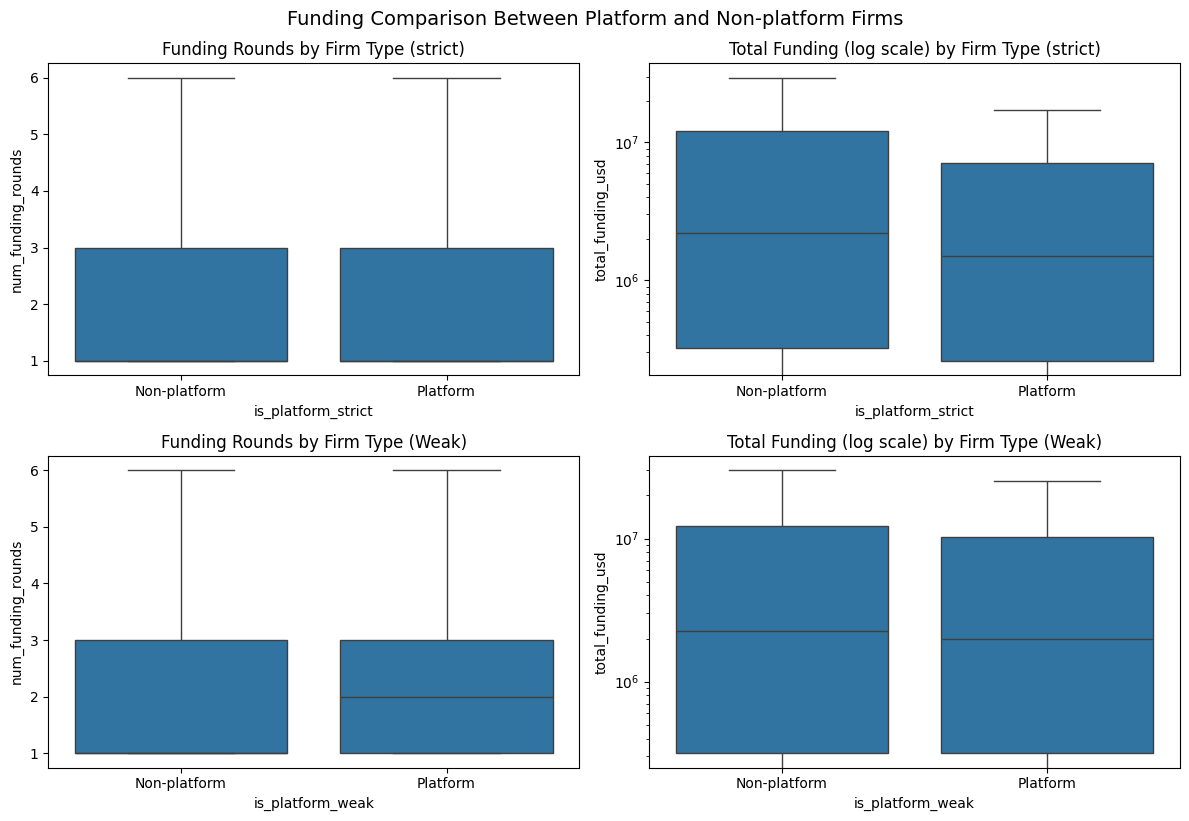

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- (1,1) strict - num_funding_rounds ---
sns.boxplot(
    data=df_org_grouped,
    x='is_platform_strict',
    y='num_funding_rounds',
    showfliers=False,
    ax=axes[0, 0]
)
axes[0, 0].set_xticklabels(['Non-platform', 'Platform'])
axes[0, 0].set_title('Funding Rounds by Firm Type (strict)')

# --- (1,2) strict - total_funding_usd ---
sns.boxplot(
    data=df_org_grouped,
    x='is_platform_strict',
    y='total_funding_usd',
    showfliers=False,
    ax=axes[0, 1]
)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xticklabels(['Non-platform', 'Platform'])
axes[0, 1].set_title('Total Funding (log scale) by Firm Type (strict)')

# --- (2,1) Weak - num_funding_rounds ---
sns.boxplot(
    data=df_org_grouped,
    x='is_platform_weak',
    y='num_funding_rounds',
    showfliers=False,
    ax=axes[1, 0]
)
axes[1, 0].set_xticklabels(['Non-platform', 'Platform'])
axes[1, 0].set_title('Funding Rounds by Firm Type (Weak)')

# --- (2,2) Weak - total_funding_usd ---
sns.boxplot(
    data=df_org_grouped,
    x='is_platform_weak',
    y='total_funding_usd',
    showfliers=False,
    ax=axes[1, 1]
)
axes[1, 1].set_yscale('log')
axes[1, 1].set_xticklabels(['Non-platform', 'Platform'])
axes[1, 1].set_title('Total Funding (log scale) by Firm Type (Weak)')

# --- Layout ---
plt.tight_layout()
plt.suptitle('Funding Comparison Between Platform and Non-platform Firms', fontsize=14, y=1.02)
plt.show()

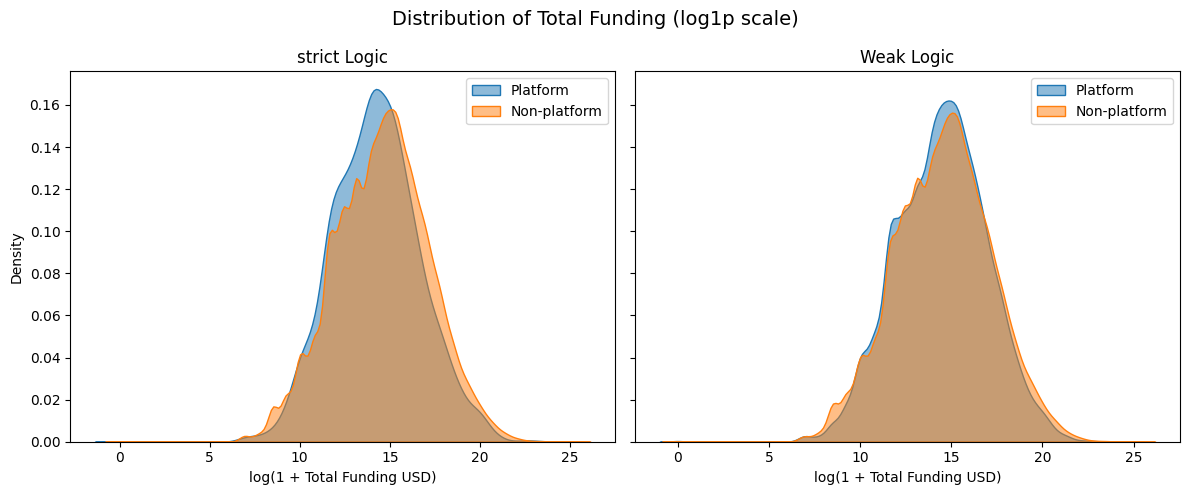

In [37]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# --- strict ---
sns.kdeplot(np.log1p(platform_strict['total_funding_usd']),
            label='Platform', fill=True, alpha=0.5, ax=axes[0])
sns.kdeplot(np.log1p(nonplatform_strict['total_funding_usd']),
            label='Non-platform', fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('strict Logic')
axes[0].set_xlabel('log(1 + Total Funding USD)')
axes[0].set_ylabel('Density')
axes[0].legend()

# --- Weak ---
sns.kdeplot(np.log1p(platform_weak['total_funding_usd']),
            label='Platform', fill=True, alpha=0.5, ax=axes[1])
sns.kdeplot(np.log1p(nonplatform_weak['total_funding_usd']),
            label='Non-platform', fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Weak Logic')
axes[1].set_xlabel('log(1 + Total Funding USD)')
axes[1].legend()

plt.suptitle('Distribution of Total Funding (log1p scale)', fontsize=14)
plt.tight_layout()
plt.show()

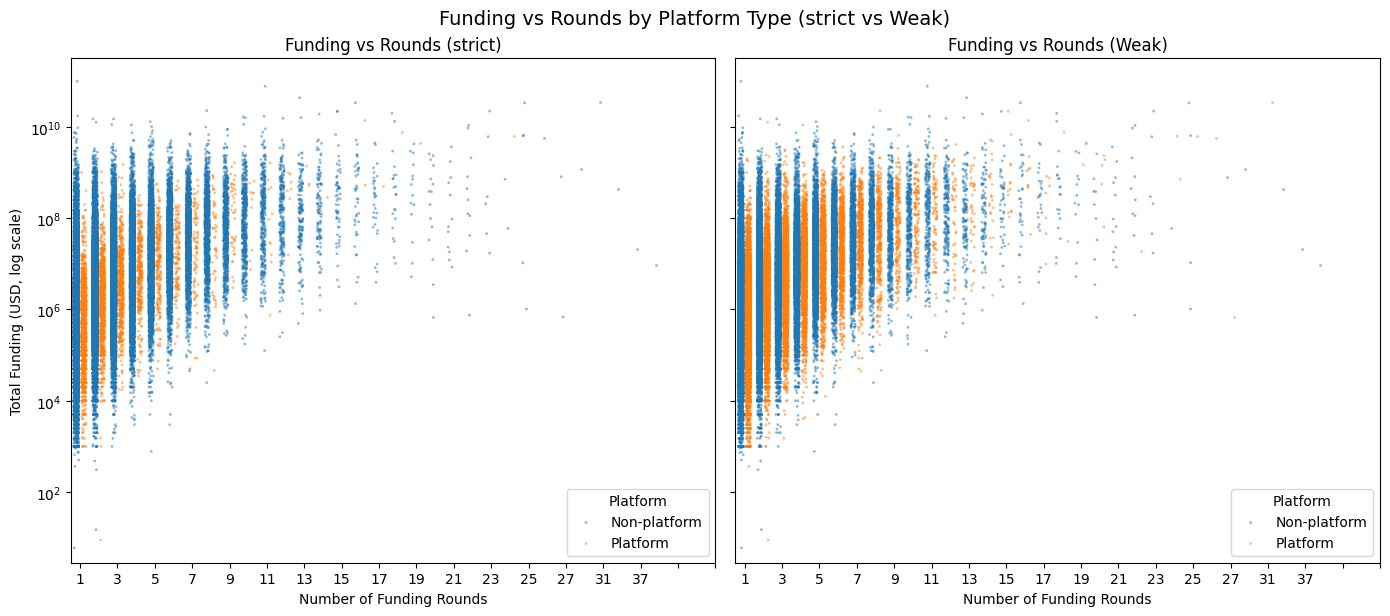

In [38]:
# Ensure integer rounds
df_org_grouped['num_funding_rounds'] = df_org_grouped['num_funding_rounds'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- (1) strict ---
sns.stripplot(
    data=df_org_grouped,
    x='num_funding_rounds',
    y='total_funding_usd',
    hue='is_platform_strict',
    dodge=True,
    jitter=0.25,
    alpha=0.5,
    size=2,
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_xticks(range(0, 36, 2))
axes[0].set_xlabel('Number of Funding Rounds')
axes[0].set_ylabel('Total Funding (USD, log scale)')
axes[0].set_title('Funding vs Rounds (strict)')
axes[0].legend(title='Platform', labels=['Non-platform', 'Platform'])

# --- (2) Weak ---
sns.stripplot(
    data=df_org_grouped,
    x='num_funding_rounds',
    y='total_funding_usd',
    hue='is_platform_weak',
    dodge=True,
    jitter=0.25,
    alpha=0.5,
    size=2,
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_xticks(range(0, 36, 2))
axes[1].set_xlabel('Number of Funding Rounds')
axes[1].set_ylabel('')
axes[1].set_title('Funding vs Rounds (Weak)')
axes[1].legend(title='Platform', labels=['Non-platform', 'Platform'])

plt.tight_layout()
plt.suptitle('Funding vs Rounds by Platform Type (strict vs Weak)', fontsize=14, y=1.02)
plt.show()

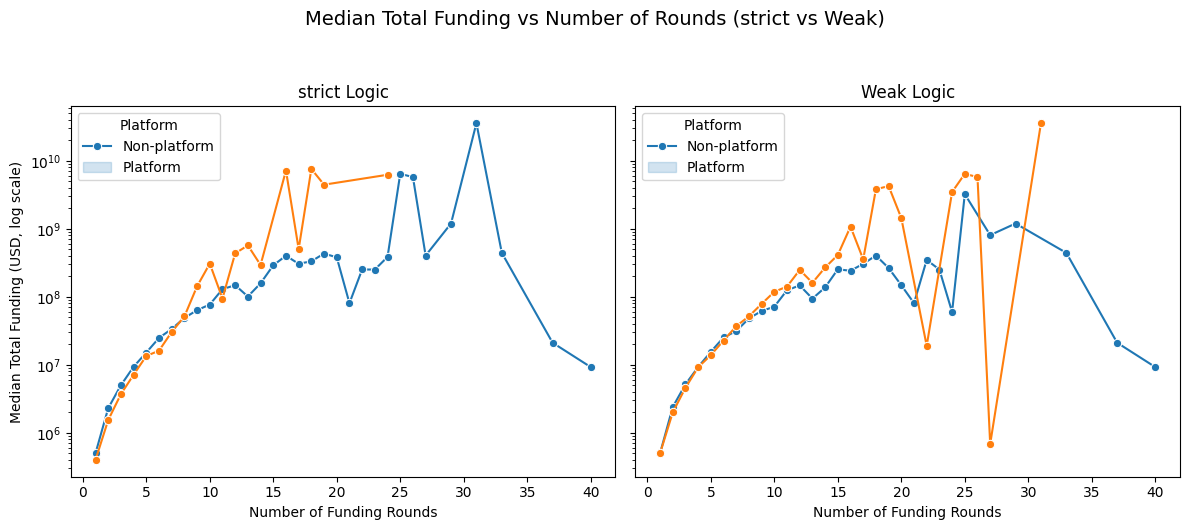

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# strict
avg_funding_strict = (
    df_org_grouped
    .groupby(['num_funding_rounds', 'is_platform_strict'])['total_funding_usd']
    .median()
    .reset_index()
)

sns.lineplot(
    data=avg_funding_strict,
    x='num_funding_rounds',
    y='total_funding_usd',
    hue='is_platform_strict',
    marker='o',
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('strict Logic')
axes[0].set_xlabel('Number of Funding Rounds')
axes[0].set_ylabel('Median Total Funding (USD, log scale)')
axes[0].legend(title='Platform', labels=['Non-platform', 'Platform'])

# Weak
avg_funding_weak = (
    df_org_grouped
    .groupby(['num_funding_rounds', 'is_platform_weak'])['total_funding_usd']
    .median()
    .reset_index()
)

sns.lineplot(
    data=avg_funding_weak,
    x='num_funding_rounds',
    y='total_funding_usd',
    hue='is_platform_weak',
    marker='o',
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Weak Logic')
axes[1].set_xlabel('Number of Funding Rounds')
axes[1].set_ylabel('')
axes[1].legend(title='Platform', labels=['Non-platform', 'Platform'])

plt.suptitle('Median Total Funding vs Number of Rounds (strict vs Weak)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Descriptives
- build a panel of firms at the quarterly level that keeps track of the number of funding rounds the firm has received, the amount of funding, exits (“status” of firm) etc. 
- distinguish non-platform businesses between:   
    -“Digital” companies (software)   
    -“Non-digital” companies: robotics, industrials, hardware, consumer staples, biotech, pharmaceuticals – anything physical   
    -(So, there will be two “control groups”. Don’t worry if this distinction is very imperfect – even something approximate will be fine.)

- Startups that are private but have not raised a funding round (or recorded any other event) in 5 years can be coded as “inactive”

### 1. build a panel of firms at the quarterly level that keeps track of the number of funding rounds the firm has received, the amount of funding, exits (“status” of firm) etc. 

In [40]:
df_quarterly = df_org_fund[['uuid', 'name', 'type','created_at', 'num_funding_rounds', 'total_funding_usd', 'founded_on', 'last_funding_on','num_exits', 'FR_name', 'FR_investment_type', 'FR_announced_on', 'FR_raised_amount_usd', 'is_vc_funded', 'num_category_platform', 'num_category_nonplatform', 'num_keyword_platform', 'num_keyword_nonplatform', 'is_platform_strict', 'is_platform_weak']].copy()
# Convert relevant dates to datetime if not already
df_quarterly['FR_announced_on'] = pd.to_datetime(df_quarterly['FR_announced_on'])

# Create quarter column using FR_announced_on
df_quarterly['quarter'] = df_quarterly['FR_announced_on'].dt.to_period('Q')

In [41]:
# Group by uuid and quarter to calculate funding metrics
quarterly_funding = df_quarterly.groupby(['uuid', 'quarter']).agg({
    'name': 'first',
    'type': 'first',
    'created_at': 'first',
    'num_funding_rounds': 'count',
    'total_funding_usd': 'first',
    'founded_on': 'first',
    'last_funding_on': 'first',
    'FR_name': lambda x: list(x),  # collect names as list
    'FR_investment_type': lambda x: list(x),  # collect names as list
    'FR_raised_amount_usd': 'sum',
    'num_exits': lambda x: x.fillna(0).sum(),  # sum exits, treating NaN as 0
    'FR_announced_on': lambda x: list(x),  # collect announced dates as list
    'is_vc_funded': 'first',
    'num_category_platform': 'first',
    'num_category_nonplatform': 'first',
    'is_platform_strict': 'first',
    'is_platform_weak': 'first'
}).reset_index()

# Sort by uuid and quarter
quarterly_funding['FR_num_round'] = quarterly_funding['FR_name'].apply(len)
quarterly_funding = quarterly_funding.sort_values(['uuid', 'quarter'])

# Add cumulative metrics
quarterly_funding['cum_num_rounds'] = quarterly_funding.groupby('uuid')['FR_num_round'].cumsum()
quarterly_funding['cum_funding'] = quarterly_funding.groupby('uuid')['FR_raised_amount_usd'].cumsum()
quarterly_funding['cum_exits'] = quarterly_funding.groupby('uuid')['num_exits'].cumsum()

In [42]:
quarterly_funding[quarterly_funding['uuid']=='845a7147-8b85-093a-54f4-d0f7e891aa20']

,uuid,quarter,name,type,created_at,num_funding_rounds,total_funding_usd,founded_on,last_funding_on,FR_name,FR_investment_type,FR_raised_amount_usd,num_exits,FR_announced_on,is_vc_funded,num_category_platform,num_category_nonplatform,is_platform_strict,is_platform_weak,FR_num_round,cum_num_rounds,cum_funding,cum_exits
132927,845a7147-8b85-093a-54f4-d0f7e891aa20,2011Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Grant - Abogen],[grant],12500.0,0.0,[2011-05-09 00:00:00],0,0,3,0,0,1,1,12500.0,0.0
132928,845a7147-8b85-093a-54f4-d0f7e891aa20,2011Q3,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Grant - Abogen],[grant],12500.0,0.0,[2011-07-11 00:00:00],0,0,3,0,0,1,2,25000.0,0.0
132929,845a7147-8b85-093a-54f4-d0f7e891aa20,2013Q1,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Debt Financing - Abogen],[debt_financing],250000.0,0.0,[2013-02-28 00:00:00],0,0,3,0,0,1,3,275000.0,0.0
132930,845a7147-8b85-093a-54f4-d0f7e891aa20,2013Q4,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],235000.0,0.0,[2013-10-01 00:00:00],1,0,3,0,0,1,4,510000.0,0.0
132931,845a7147-8b85-093a-54f4-d0f7e891aa20,2014Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],50000.0,0.0,[2014-04-01 00:00:00],1,0,3,0,0,1,5,560000.0,0.0
132932,845a7147-8b85-093a-54f4-d0f7e891aa20,2014Q3,Abogen,organization,2016-11-28 06:40:03,2,1405000.0,2011-01-01,2016-07-01,"[Angel Round - Abogen, Seed Round - Abogen]","[angel, seed]",225000.0,0.0,"[2014-07-01 00:00:00, 2014-07-22 00:00:00]",1,0,3,0,0,2,7,785000.0,0.0
132933,845a7147-8b85-093a-54f4-d0f7e891aa20,2015Q1,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Angel Round - Abogen],[angel],30000.0,0.0,[2015-01-01 00:00:00],1,0,3,0,0,1,8,815000.0,0.0
132934,845a7147-8b85-093a-54f4-d0f7e891aa20,2015Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Debt Financing - Abogen],[debt_financing],25000.0,0.0,[2015-06-30 00:00:00],0,0,3,0,0,1,9,840000.0,0.0
132935,845a7147-8b85-093a-54f4-d0f7e891aa20,2016Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],450000.0,0.0,[2016-06-01 00:00:00],1,0,3,0,0,1,10,1290000.0,0.0
132936,845a7147-8b85-093a-54f4-d0f7e891aa20,2016Q3,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],115000.0,0.0,[2016-07-01 00:00:00],1,0,3,0,0,1,11,1405000.0,0.0


Text(0.5, 1.0, 'Quarterly Exits (M&A/IPO) by Firm Type')

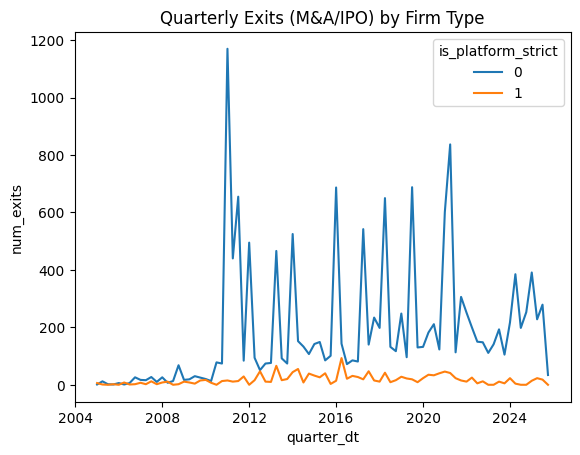

In [43]:
quarterly_funding['quarter_dt'] = pd.PeriodIndex(quarterly_funding['quarter'], freq='Q').to_timestamp()
exit_trend = quarterly_funding.groupby(['quarter_dt','is_platform_strict'])['num_exits'].sum().reset_index()
sns.lineplot(data=exit_trend, x='quarter_dt', y='num_exits', hue='is_platform_strict')
plt.title('Quarterly Exits (M&A/IPO) by Firm Type')

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/2297282485.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/2297282485.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


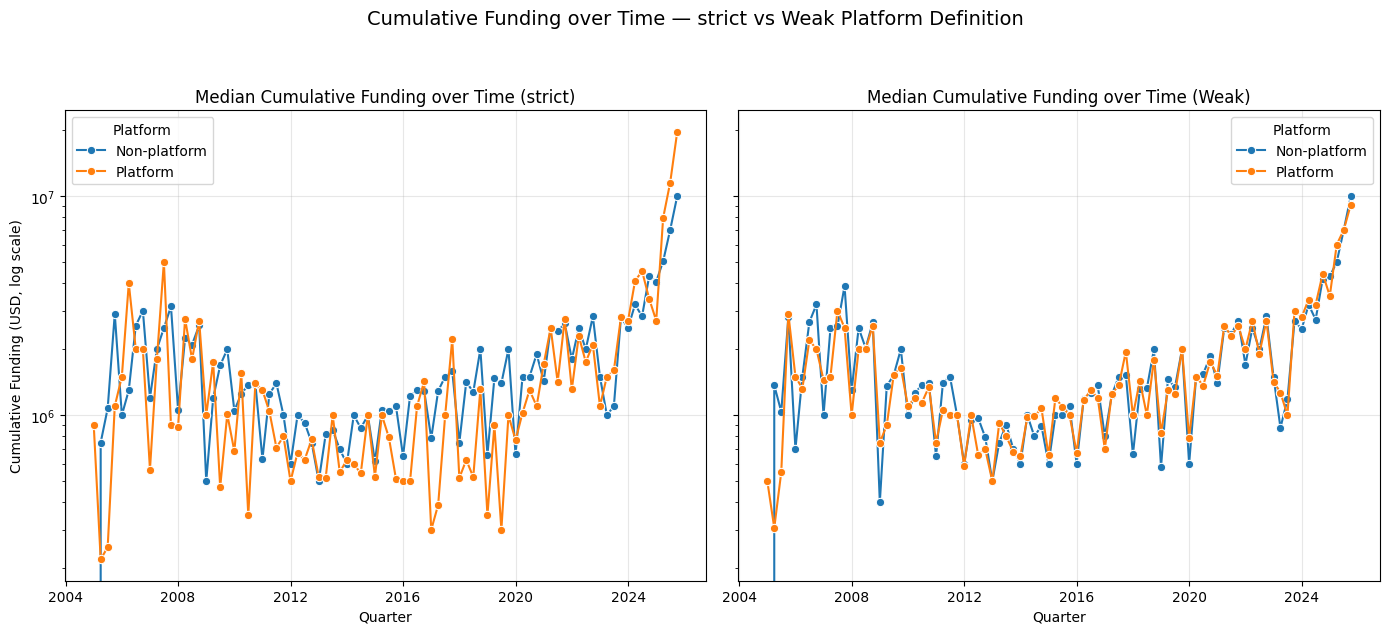

In [44]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- strict ----------------
sns.lineplot(
    data=quarterly_funding, 
    x='quarter_dt', 
    y='cum_funding', 
    hue='is_platform_strict',
    estimator='median',
    ci=None,
    ax=axes[0],
    marker='o'
)
axes[0].set_title('Median Cumulative Funding over Time (strict)')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Cumulative Funding (USD, log scale)')
axes[0].set_yscale('log')
axes[0].legend(title='Platform', labels=['Non-platform','Platform'])
axes[0].grid(alpha=0.3)

# ---------------- Weak ----------------
sns.lineplot(
    data=quarterly_funding, 
    x='quarter_dt', 
    y='cum_funding', 
    hue='is_platform_weak',
    estimator='median',
    ci=None,
    ax=axes[1],
    marker='o'
)
axes[1].set_title('Median Cumulative Funding over Time (Weak)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('')
axes[1].set_yscale('log')
axes[1].legend(title='Platform', labels=['Non-platform','Platform'])
axes[1].grid(alpha=0.3)

# Adjust layout
plt.suptitle('Cumulative Funding over Time — strict vs Weak Platform Definition', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/459428113.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_16093/459428113.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


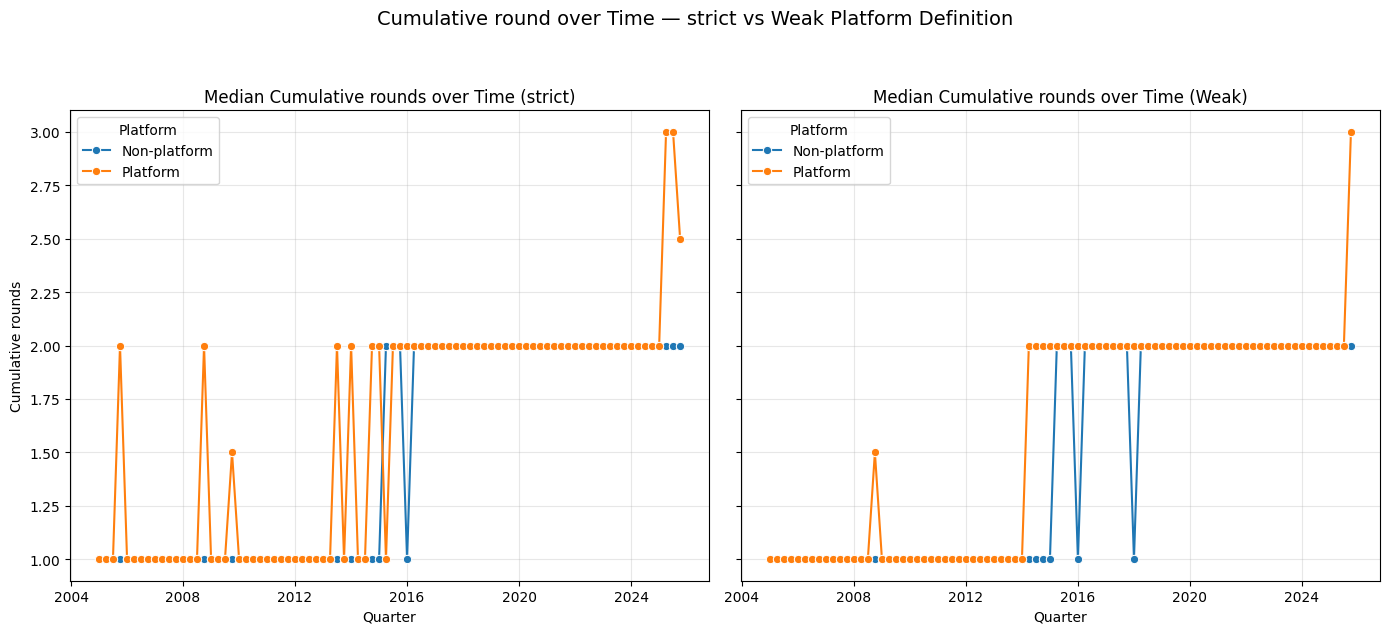

In [45]:

quarterly_funding['quarter_dt'] = pd.PeriodIndex(quarterly_funding['quarter'], freq='Q').to_timestamp()
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- strict ----------------
sns.lineplot(
    data=quarterly_funding, 
    x='quarter_dt', 
    y='cum_num_rounds', 
    hue='is_platform_strict',
    estimator='median',
    ci=None,
    ax=axes[0],
    marker='o'
)
axes[0].set_title('Median Cumulative rounds over Time (strict)')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Cumulative rounds')
axes[0].legend(title='Platform', labels=['Non-platform','Platform'])
axes[0].grid(alpha=0.3)

# ---------------- Weak ----------------
sns.lineplot(
    data=quarterly_funding, 
    x='quarter_dt', 
    y='cum_num_rounds', 
    hue='is_platform_weak',
    estimator='median',
    ci=None,
    ax=axes[1],
    marker='o'
)
axes[1].set_title('Median Cumulative rounds over Time (Weak)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('')
axes[1].legend(title='Platform', labels=['Non-platform','Platform'])
axes[1].grid(alpha=0.3)

# Adjust layout
plt.suptitle('Cumulative round over Time — strict vs Weak Platform Definition', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [46]:
non_platform_weak = quarterly_funding[quarterly_funding['is_platform_weak'] == 0]
platform_weak = quarterly_funding[quarterly_funding['is_platform_weak'] == 1]
non_platform_weak[['cum_num_rounds','cum_funding','cum_exits']].describe()


,cum_num_rounds,cum_funding,cum_exits
count,184404.000000,1.844040e+05,184404.000000
mean,2.519484,4.649706e+07,0.194692
std,2.304971,5.450390e+08,11.865725
min,1.000000,0.000000e+00,0.000000
25%,1.000000,7.500000e+04,0.000000
50%,2.000000,1.500000e+06,0.000000
75%,3.000000,1.000000e+07,0.000000
max,40.000000,1.000000e+11,2912.000000


In [47]:
platform_weak[['cum_num_rounds','cum_funding','cum_exits']].describe()

,cum_num_rounds,cum_funding,cum_exits
count,73438.000000,7.343800e+04,73438.000000
mean,2.495289,3.488863e+07,0.416801
std,2.114059,4.397216e+08,20.291084
min,1.000000,0.000000e+00,0.000000
25%,1.000000,1.000000e+05,0.000000
50%,2.000000,1.400000e+06,0.000000
75%,3.000000,8.000000e+06,0.000000
max,31.000000,3.576245e+10,3378.000000


Conclusion: 


## Interesting descriptives:
### Age
1. Conditional on startup age (for example, for all startups of age 5 years), what is the average number of funding rounds for platform vs. non-platform businesses? (Start with “VC only”; later could separately study all funding rounds) Total amount of funding for platform vs. non-platform businesses?
2. “Round cadence”: in a given company age, (number of rounds since start) / (years since first funding round)  Separately for platform vs. control groups
3. Conditional on startup age (for example, all startups of age 5 years), what is the rate of 
   - Being closed / inactive,
   - Being acquired,
   - Having gone public?

In [48]:
# for item 3 above 
df_company_age_status= df_org_grouped[['uuid', 'name', 'company_age','status', 'is_inactive', 'is_vc_funded', 'is_platform_strict', 'is_platform_weak', 'is_digital_nonplatform']].copy()
df_company_age_status['new_status'] = np.where(
    df_company_age_status['is_inactive'] | df_company_age_status['status'].isin(['closed']),
    'close/inactive',
    df_company_age_status['status']
)

TypeError: unsupported operand type(s) for |: 'float' and 'bool'

In [ ]:
status_counts

,company_age,is_platform_strict,new_status,count,percent
0,0,0,acquired,1,0.001018
1,0,0,close/inactive,8,0.008147
2,0,0,ipo,5,0.005092
3,0,0,operating,968,0.985743
4,0,1,operating,28,1.000000
...,...,...,...,...,...
154,20,0,operating,482,0.225234
155,20,1,acquired,2,0.030769
156,20,1,close/inactive,57,0.876923
157,20,1,ipo,2,0.030769


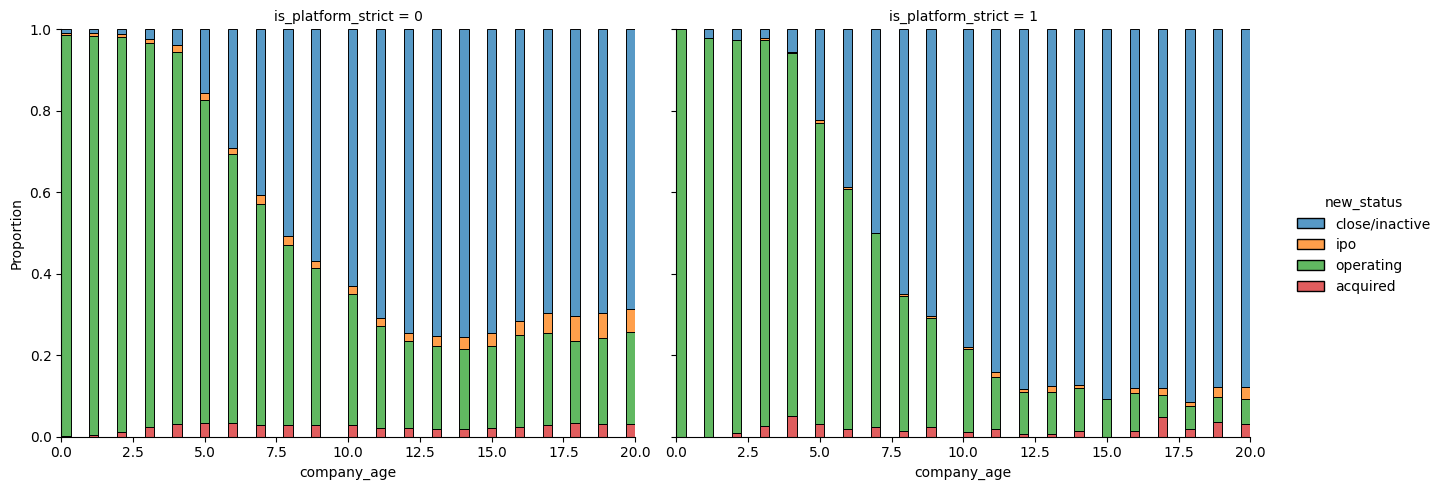

In [ ]:
sns.displot(
    data=df_company_age_status,
    x='company_age',
    hue='new_status',
    col='is_platform_strict',
    kind='hist',
    stat='proportion',
    multiple='fill',
    height=5,
    aspect=1.3
)

In [ ]:
status_counts = (
    df_company_age_status
    .groupby(['company_age', 'is_platform_strict', 'new_status'])
    .size()
    .reset_index(name='count')
)
status_counts['percent'] = (
    status_counts.groupby(['company_age', 'is_platform_strict'])['count']
    .transform(lambda x: x / x.sum())
)

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_86722/218349360.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


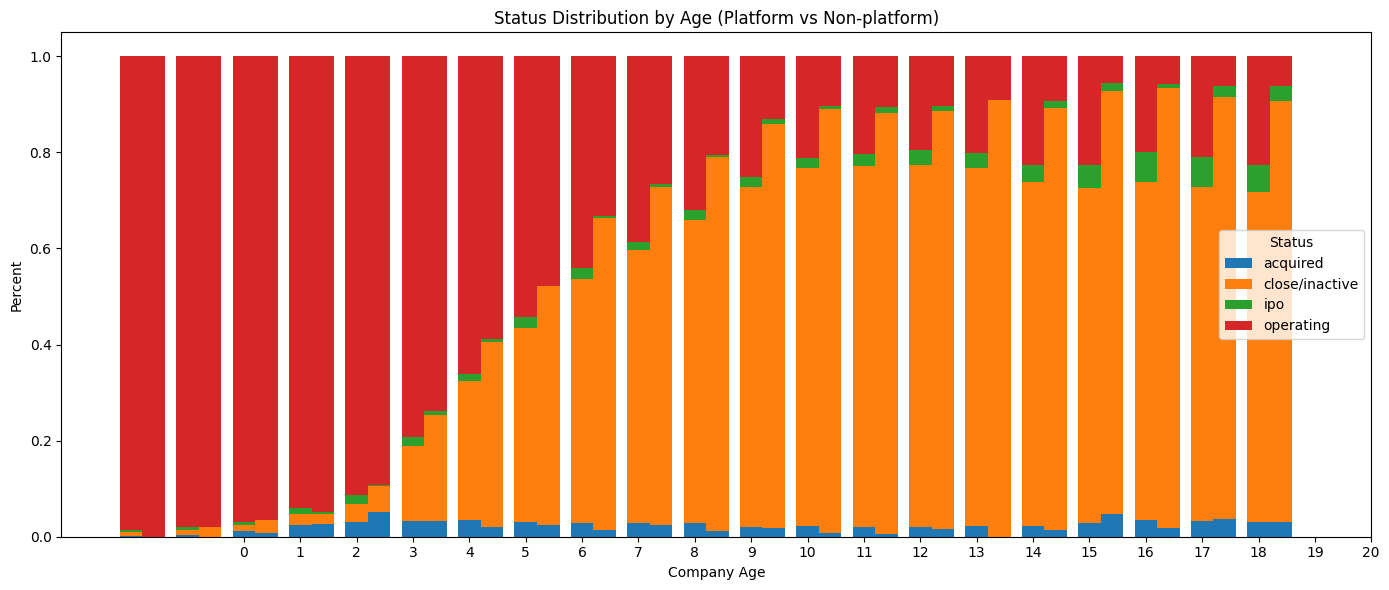

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = status_counts.copy()

pivot = df.pivot_table(
    index=["company_age", "is_platform_strict"],
    columns="new_status",
    values="percent",
    fill_value=0,
).reset_index()

statuses = pivot.columns[2:] 

ages = sorted(pivot["company_age"].unique())
platforms = [1，0]
bar_width = 0.4

# 固定颜色（status → color），防止matplotlib自动cycle乱掉
cmap = plt.cm.get_cmap("tab10")
colors = {status: cmap(i) for i, status in enumerate(statuses)}

fig, ax = plt.subplots(figsize=(14, 6))
x_base = np.arange(len(ages))

for p_idx, p in enumerate(platforms):

    subset = pivot[pivot["is_platform_strict"] == p]
    x_pos = x_base + (p_idx - 0.5) * bar_width
    bottom = np.zeros(len(subset))

    for st in statuses:
        vals = subset[st].values
        ax.bar(
            x_pos, vals, bar_width,
            bottom=bottom,
            color=colors[st],         # ← 颜色固定
            label=st if p_idx == 0 else None   # ← legend 只给第一个bar
        )
        bottom += vals

ax.set_xticks(x_base)
ax.set_xticklabels(ages)
ax.set_xlabel("Company Age")
ax.set_ylabel("Percent")
ax.set_title("Status Distribution by Age (Platform vs Non-platform)")
ax.legend(title="Status")

plt.tight_layout()
plt.show()

In [ ]:
df_company_age = df_org_grouped[['uuid', 'name','short_description', 'created_at', 'company_age','num_funding_rounds', 'first_round_on','total_funding_usd', 'num_exits', 'is_inactive', 'is_vc_funded', 'is_platform_strict', 'is_platform_weak', 'is_digital_nonplatform']].copy()
# only consider vc funded companies
df_company_age = df_company_age[df_company_age['is_vc_funded'] == 1]
today = pd.Timestamp.today()
df_company_age['years_since_first_round'] = ((today - df_company_age['first_round_on']).dt.days / 365)
df_company_age['round_cadence'] = df_company_age['num_funding_rounds']/df_company_age['years_since_first_round']

In [ ]:
df_company_age[['name', 'is_platform_strict', 'round_cadence']]

,name,is_platform_strict,round_cadence
0,Resilio (acquired by meQuilibrium),0,0.663234
2,Codementor,0,0.406821
3,Futuremood,0,0.297231
5,Lillii RNB,0,0.420992
6,SnapClarity,0,0.450478
...,...,...,...
120580,Sustainable Industries,0,0.133602
120583,Snapifeye,0,0.094291
120584,StackMob,1,0.068894
120585,Social 2 Step,0,0.079642


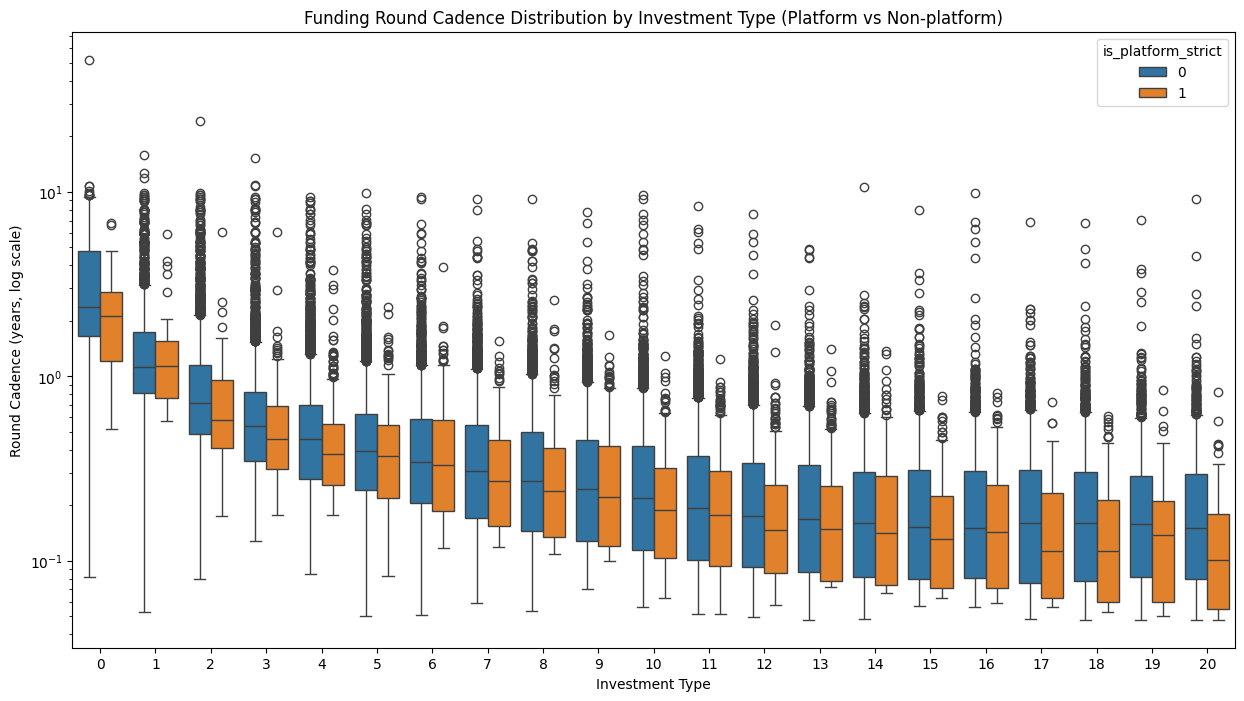

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df_company_age,
    hue='is_platform_strict',
    y='round_cadence',
    x='company_age'
)
plt.yscale('log')
plt.title("Funding Round Cadence Distribution by Investment Type (Platform vs Non-platform)")
plt.xlabel("Investment Type")
plt.ylabel("Round Cadence (years, log scale)")
plt.show()

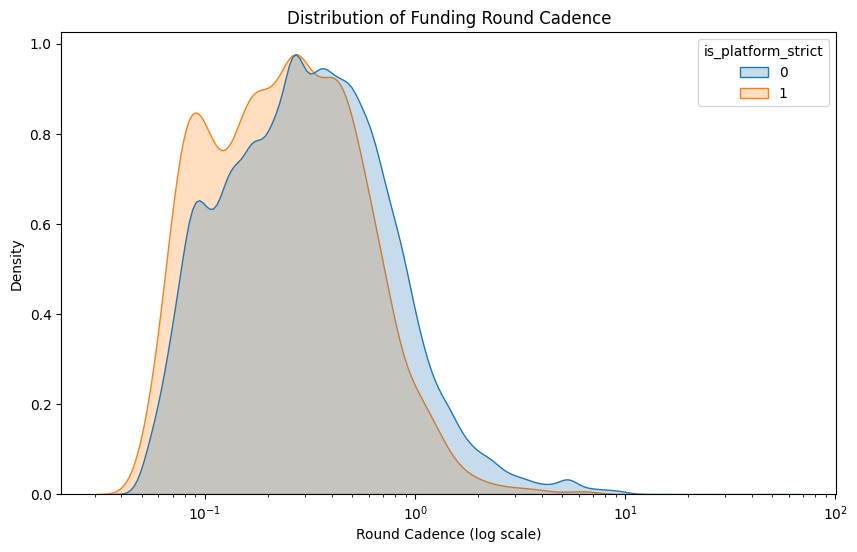

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_company_age,
    x='round_cadence',
    hue='is_platform_strict',
    log_scale=True,
    fill=True,
    common_norm=False
)
plt.title("Distribution of Funding Round Cadence")
plt.xlabel("Round Cadence (log scale)")
plt.show()

In [ ]:
platform_col = 'is_platform_strict'
df_age_grouped = df_company_age.groupby(['company_age', platform_col]).agg({
    'uuid': 'count',
    'num_funding_rounds': 'mean',
    'total_funding_usd': 'mean',
    'num_exits': 'mean',
}).reset_index()
df_age_grouped = df_age_grouped.fillna(0)

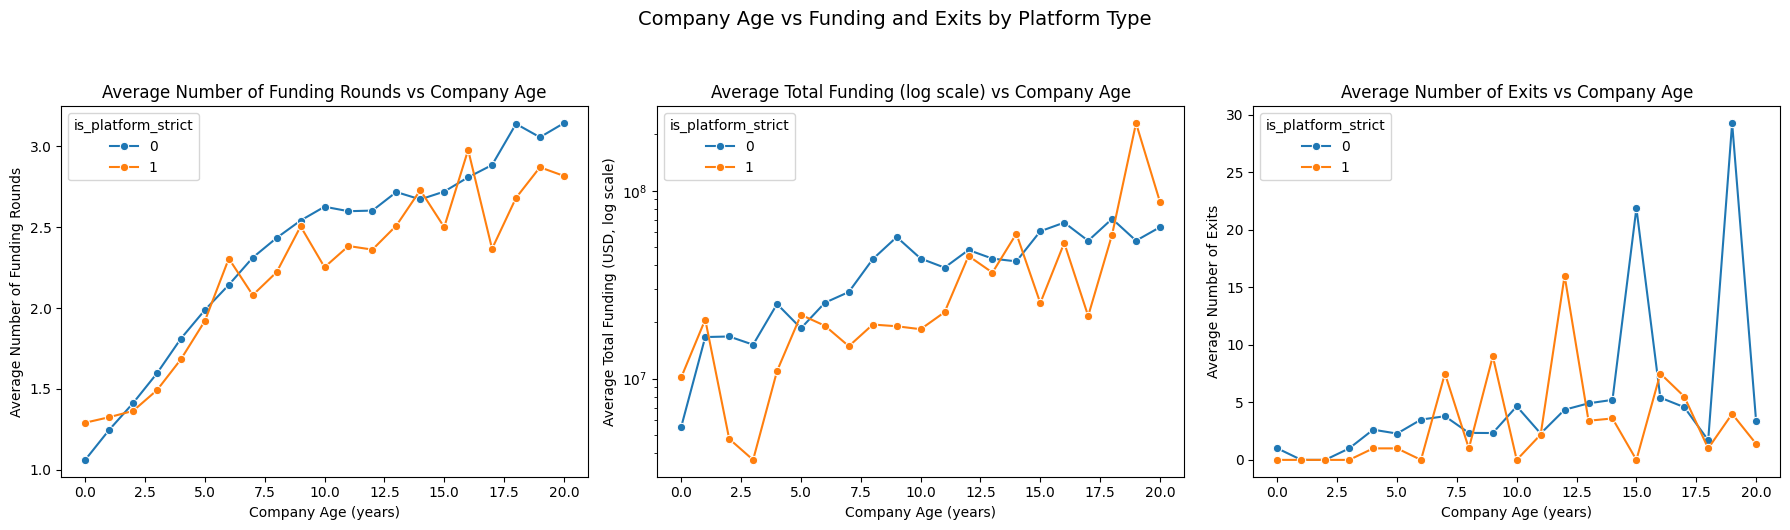

In [ ]:
# plot lines for num_funding_rounds, total_funding_usd, num_exits vs company_age
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(
    data=df_age_grouped,
    x='company_age',
    y='num_funding_rounds',
    hue=platform_col,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average Number of Funding Rounds vs Company Age')
axes[0].set_xlabel('Company Age (years)')
axes[0].set_ylabel('Average Number of Funding Rounds')
# axes[0].legend(title='Platform', labels=['Non-platform','Platform'])
sns.lineplot(
    data=df_age_grouped,
    x='company_age',
    y='total_funding_usd',
    hue=platform_col,
    marker='o',
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Average Total Funding (log scale) vs Company Age')
axes[1].set_xlabel('Company Age (years)')
axes[1].set_ylabel('Average Total Funding (USD, log scale)')
# axes[1].legend(title='Platform', labels=['Non-platform','Platform'])
sns.lineplot(
    data=df_age_grouped,
    x='company_age',
    y='num_exits',
    hue=platform_col,
    marker='o',
    ax=axes[2]
)
axes[2].set_title('Average Number of Exits vs Company Age')
axes[2].set_xlabel('Company Age (years)')
axes[2].set_ylabel('Average Number of Exits')
# axes[2].legend(title='Platform', labels=['Non-platform','Platform'])
plt.suptitle('Company Age vs Funding and Exits by Platform Type', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

- What is the average and median size of funding rounds of types series_a, series_b, series_c for platform vs. non-platform businesses?

In [ ]:
df_fund_rounds = df_org_fund[['FR_org_uuid', 'name', 'FR_investment_type', 'FR_raised_amount_usd', 'is_platform_strict', 'is_platform_weak']].copy()
# keep only some founds 
keep_investment_types = ['angel', 'pre_seed', 'seed', 'series_a', 'series_b', 'series_c','series_d','series_e','series_f','series_g','series_h','series_i', 'series_j']
df_fund_rounds = df_fund_rounds[df_fund_rounds['FR_investment_type'].isin(keep_investment_types)]
df_fund_rounds['FR_investment_type'] = pd.Categorical(
    df_fund_rounds['FR_investment_type'],
    categories=keep_investment_types,
    ordered=True
)

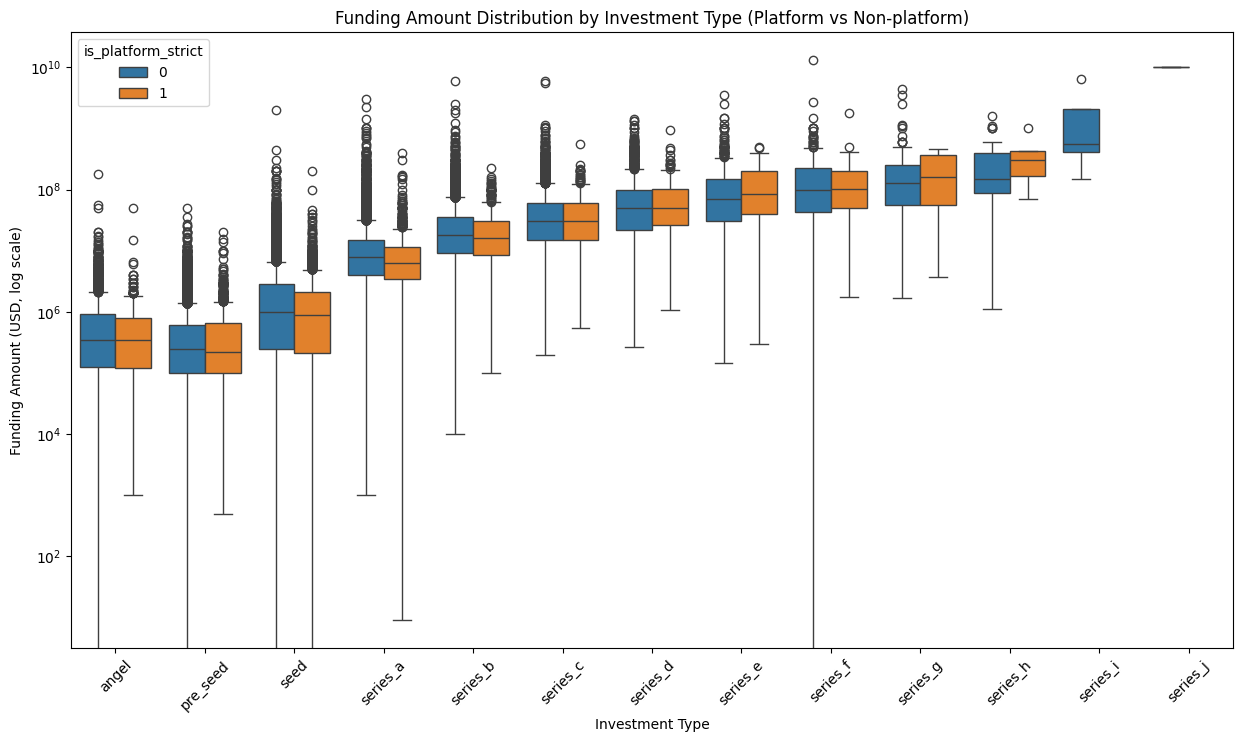

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df_fund_rounds[df_fund_rounds['FR_investment_type'].isin(keep_investment_types)],
    x='FR_investment_type',
    y='FR_raised_amount_usd',
    hue='is_platform_strict'
)
plt.yscale('log')
plt.title("Funding Amount Distribution by Investment Type (Platform vs Non-platform)")
plt.xlabel("Investment Type")
plt.ylabel("Funding Amount (USD, log scale)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
platform_col = 'is_platform_strict'
df_rounds_grouped = df_fund_rounds.groupby(['FR_investment_type', platform_col]).agg({
    'FR_org_uuid': 'count',
    'FR_raised_amount_usd': ['mean',lambda x: x.quantile(0.25), 'median',lambda x: x.quantile(0.75)],
}).reset_index()
df_rounds_grouped.columns = ['FR_investment_type', platform_col, 'company_count', 'raised_amount_mean', 'raised_amount_25', 'raised_amount_median', 'raised_amount_75']

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_86722/2780783186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_rounds_grouped = df_fund_rounds.groupby(['FR_investment_type', platform_col]).agg({


In [ ]:
df_rounds_grouped

,FR_investment_type,is_platform_strict,company_count,raised_amount_mean,raised_amount_25,raised_amount_median,raised_amount_75
0,angel,0,5833,8.391223e+05,1.250000e+05,3.500000e+05,9.192500e+05
1,angel,1,581,7.448654e+05,1.225000e+05,3.500000e+05,8.000000e+05
2,pre_seed,0,26807,6.106548e+05,1.000000e+05,2.500000e+05,6.150000e+05
3,pre_seed,1,1600,5.929917e+05,1.000000e+05,2.200000e+05,6.509580e+05
4,seed,0,71468,2.238378e+06,2.500000e+05,1.000000e+06,2.802519e+06
5,seed,1,4311,1.792020e+06,2.090000e+05,8.707340e+05,2.100000e+06
6,series_a,0,23412,1.424861e+07,4.000000e+06,8.000000e+06,1.500000e+07
7,series_a,1,1138,1.074412e+07,3.500000e+06,6.199095e+06,1.150000e+07
8,series_b,0,11095,3.078870e+07,9.000000e+06,1.820000e+07,3.500000e+07
9,series_b,1,498,2.529747e+07,8.600000e+06,1.600000e+07,3.000000e+07


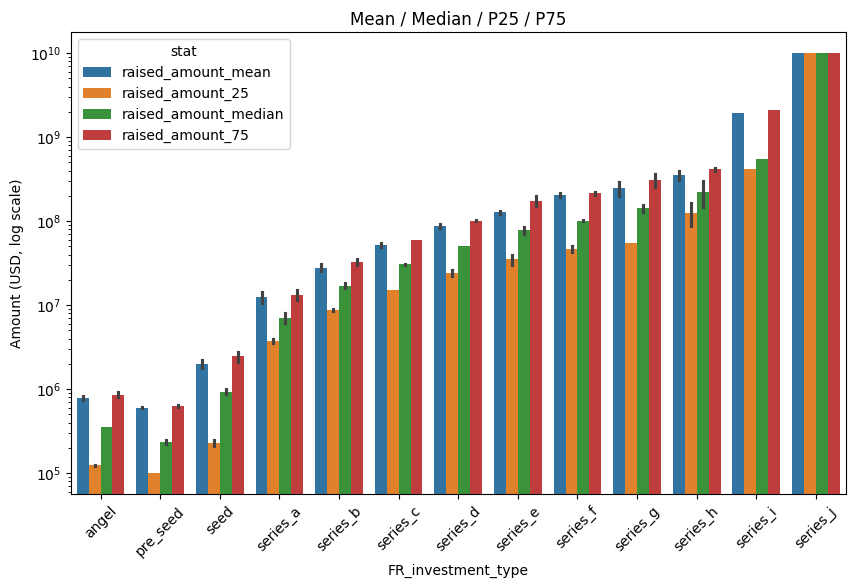

In [ ]:
quant_long = df_rounds_grouped.melt(
    id_vars=['FR_investment_type', 'is_platform_strict'],
    value_vars=['raised_amount_mean', 'raised_amount_25', 'raised_amount_median', 'raised_amount_75'],
    var_name='stat',
    value_name='amount'
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=quant_long,
    x='FR_investment_type',
    y='amount',
    hue='stat',
)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Mean / Median / P25 / P75")
plt.ylabel("Amount (USD, log scale)")
plt.show()

Conditional on going public, what is the
- Amount of funding,
- Number of rounds,
- Years since first round for platform vs. non-platform businesses?

In [ ]:
df_ipo = df_org_grouped[['uuid', 'name','short_description', 'created_at', 'status','company_age','num_funding_rounds', 'first_round_on','total_funding_usd', 'num_exits', 'is_inactive', 'is_vc_funded', 'is_platform_strict', 'is_platform_weak', 'is_digital_nonplatform']].copy()
df_ipo = df_ipo[df_ipo['status']=='ipo']
df_ipo['years_since_first_round'] = ((today - df_ipo['first_round_on']).dt.days / 365)
platform_col = 'is_platform_strict'

In [ ]:
df_ipo.head()

,uuid,name,short_description,created_at,status,company_age,num_funding_rounds,first_round_on,total_funding_usd,num_exits,is_inactive,is_vc_funded,is_platform_strict,is_platform_weak,is_digital_nonplatform,years_since_first_round
1,00002106-f78f-4fe7-9b14-190ec6d4aff1,Greenheart Gold,Greenheart Gold is a mining company that explores and develops minerals and gold projects.,2024-09-10 04:41:33,ipo,1,1,2024-09-25,2.673128e+07,NaN,0,0,0,0,0,1.142466
26,000d602f-7313-49bf-95dc-0bc0106b30f5,ONGold Resources,ONGold Resources is a mining company that explores and develops gold mines.,2024-05-10 03:45:42,ipo,3,2,2024-12-10,9.025885e+06,NaN,0,0,0,0,0,0.934247
68,00255195-c1ba-4fcc-8a05-066eedbeee26,Vanguard Mining,Vanguard Mining Corp is a mineral exploration firm focused on the discovery and development of high-value uranium prospects.,2024-08-14 11:17:06,ipo,15,2,2025-07-22,1.733465e+06,NaN,0,0,0,0,0,0.320548
87,002e0b73-ab4e-bfd5-0d9a-e6df8fede446,BioAtla,"BioAtla develops safer, more effective drugs for cancer using a proprietary next-generation antibody discovery and evolution platform.",2015-07-22 12:25:35,ipo,18,7,2015-06-11,3.357000e+08,NaN,0,1,0,0,0,10.441096
130,00441a55-dc2d-e4e6-6450-967db4ac6012,Four Corners Property Trust,Four Corners Property Trust is a real estate investment trust that engages primarily in management.,2016-04-09 07:43:17,ipo,10,2,2024-03-14,1.025000e+09,NaN,0,0,0,0,1,1.676712


In [ ]:
df_ipo[platform_col].value_counts()

is_platform_strict
0    3171
1      56
Name: count, dtype: int64

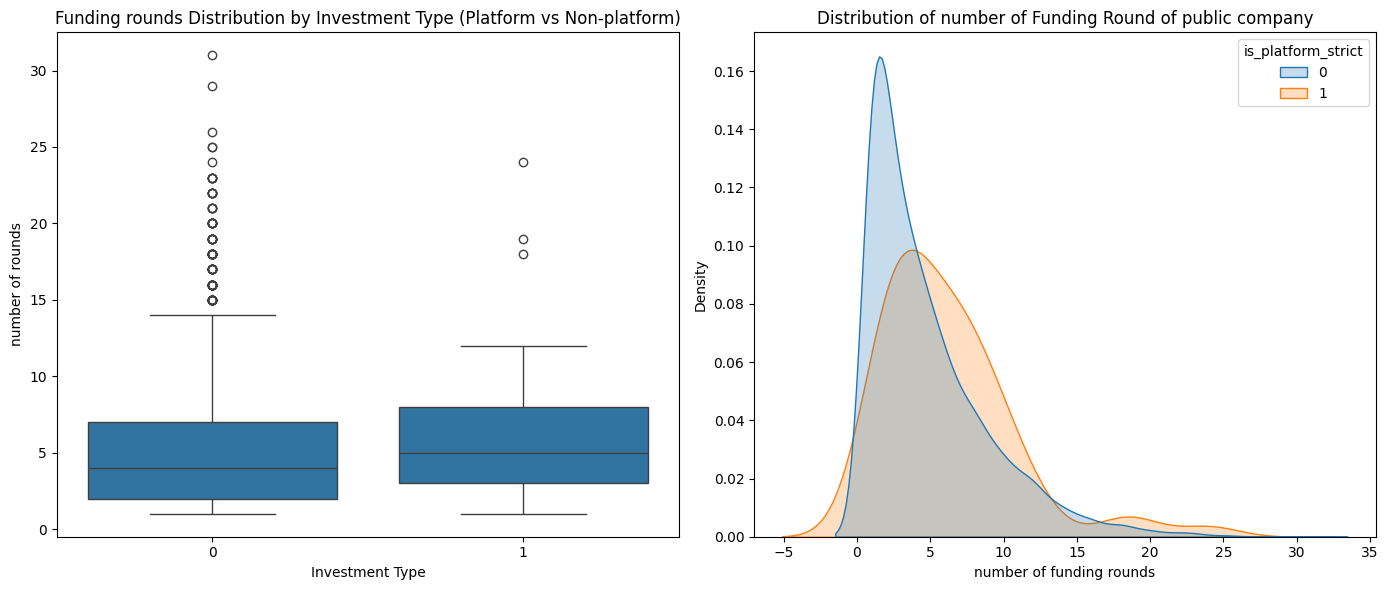

In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot ---
sns.boxplot(
    data=df_ipo,
    y='num_funding_rounds',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Funding rounds Distribution by Investment Type (Platform vs Non-platform)")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("number of rounds")

# --- KDE plot ---
sns.kdeplot(
    data=df_ipo,
    x='num_funding_rounds',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of number of Funding Round of public company")
axs[1].set_xlabel("number of funding rounds")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

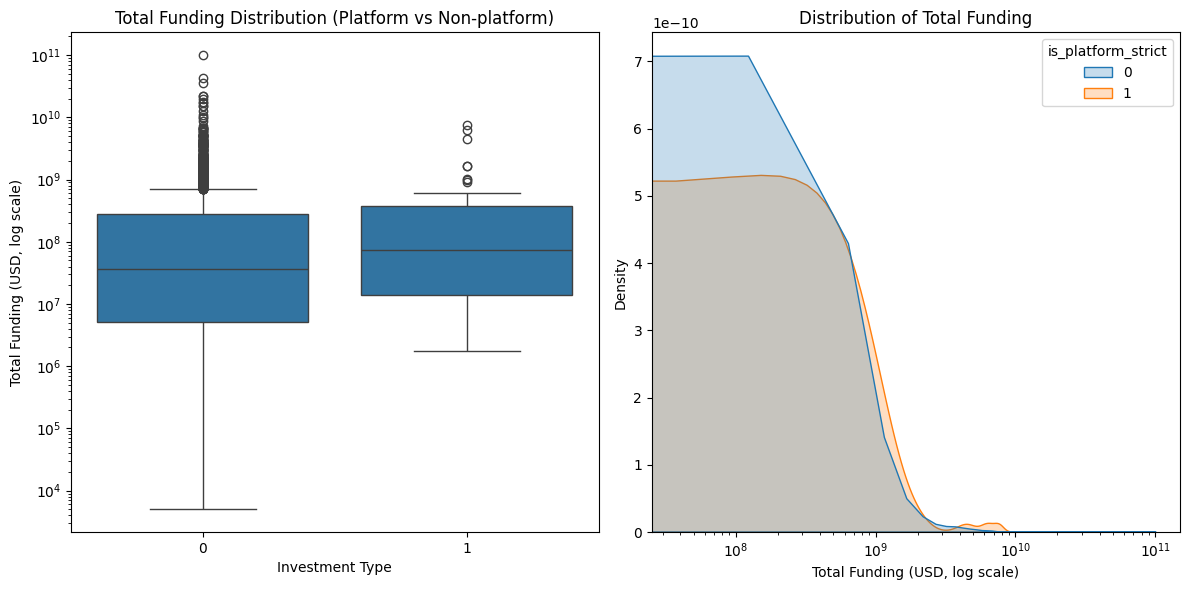

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Total Funding
# ---------------------------------------------------
sns.boxplot(
    data=df_ipo,
    y='total_funding_usd',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Total Funding Distribution (Platform vs Non-platform)")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Total Funding (USD, log scale)")
axs[0].set_yscale("log")          # Funding is usually very skewed

# ---------------------------------------------------
# 2) KDE PLOT — Total Funding
# ---------------------------------------------------
sns.kdeplot(
    data=df_ipo,
    x='total_funding_usd',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Total Funding")
axs[1].set_xlabel("Total Funding (USD, log scale)")
axs[1].set_ylabel("Density")
axs[1].set_xscale("log")          # KDE also needs log-scale

# ---------------------------------------------------
plt.tight_layout()
plt.show()

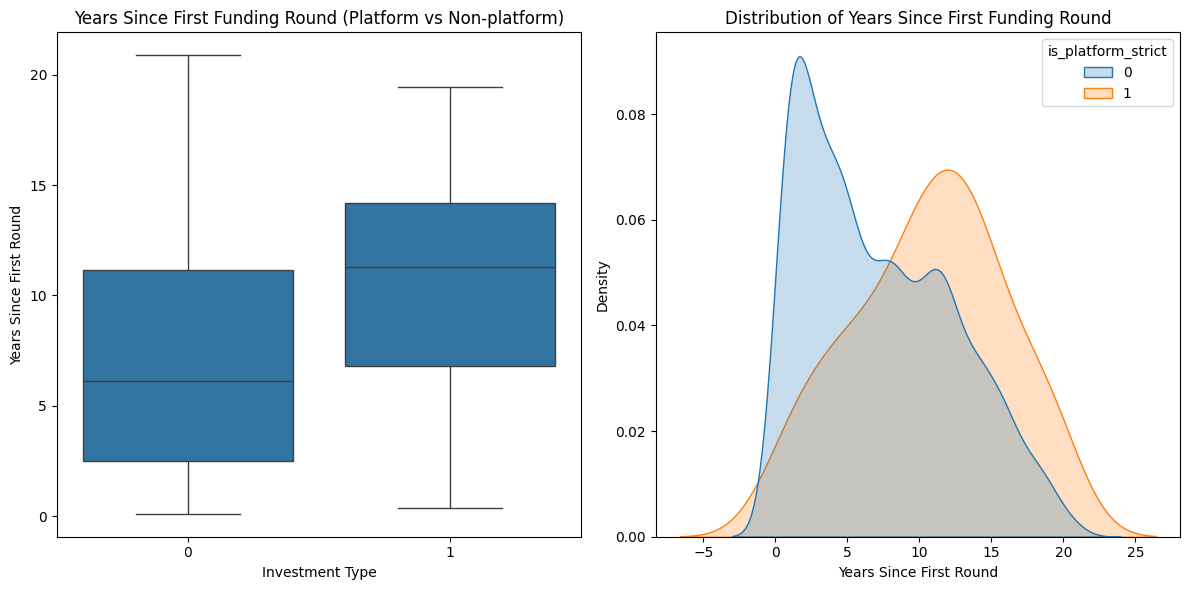

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Years Since First Round
# ---------------------------------------------------
sns.boxplot(
    data=df_ipo,
    y='years_since_first_round',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Years Since First Funding Round (Platform vs Non-platform)")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Years Since First Round")

# ---------------------------------------------------
# 2) KDE PLOT — Years Since First Round
# ---------------------------------------------------
sns.kdeplot(
    data=df_ipo,
    x='years_since_first_round',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Years Since First Funding Round")
axs[1].set_xlabel("Years Since First Round")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

Conditional on being acquired, what is the 
- Amount of funding,
- Number of funding rounds,
- Years since first round for platform vs. non-platform businesses?

In [ ]:
df_acquired = df_org_grouped[['uuid', 'name','short_description', 'created_at', 'status','company_age','num_funding_rounds', 'first_round_on','total_funding_usd', 'num_exits', 'is_inactive', 'is_vc_funded', 'is_platform_strict', 'is_platform_weak', 'is_digital_nonplatform']].copy()
df_acquired = df_acquired[df_acquired['status']=='acquired']
df_acquired['years_since_first_round'] = ((today - df_acquired['first_round_on']).dt.days / 365)
platform_col = 'is_platform_strict'

In [ ]:
df_acquired[platform_col].value_counts()

is_platform_strict
0    8661
1     432
Name: count, dtype: int64

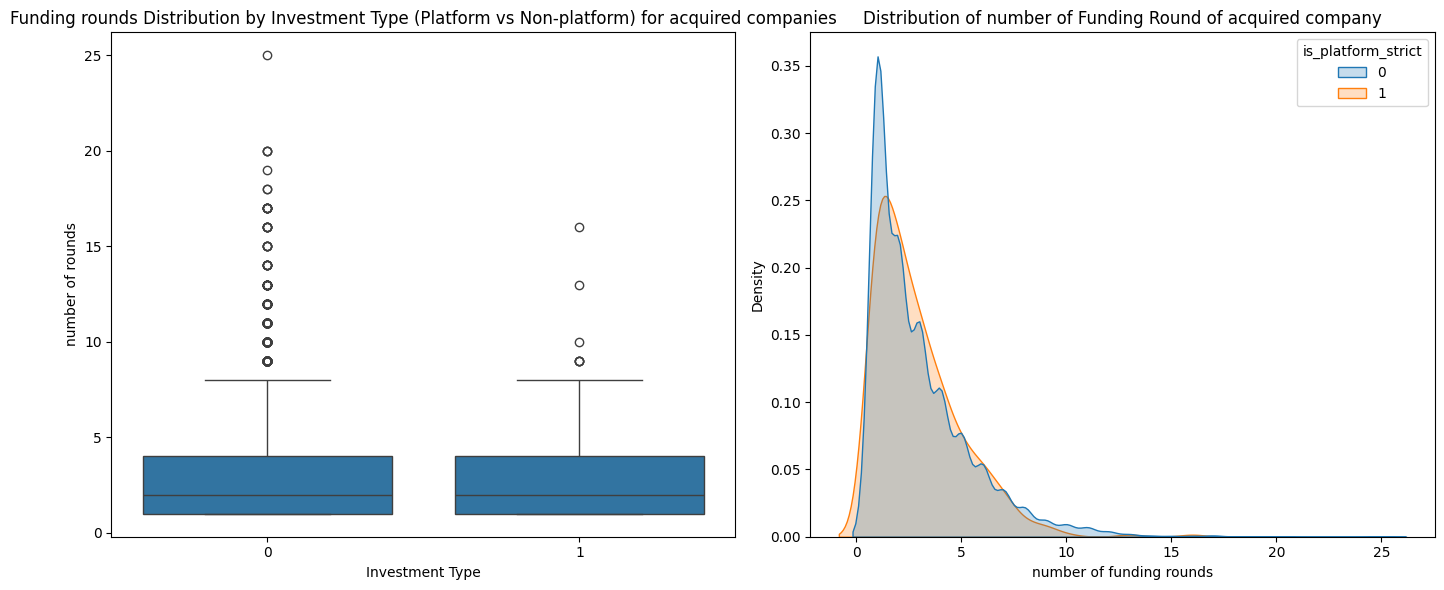

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot ---
sns.boxplot(
    data=df_acquired,
    y='num_funding_rounds',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Funding rounds Distribution by Investment Type (Platform vs Non-platform) for acquired companies")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("number of rounds")

# --- KDE plot ---
sns.kdeplot(
    data=df_acquired,
    x='num_funding_rounds',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of number of Funding Round of acquired company")
axs[1].set_xlabel("number of funding rounds")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

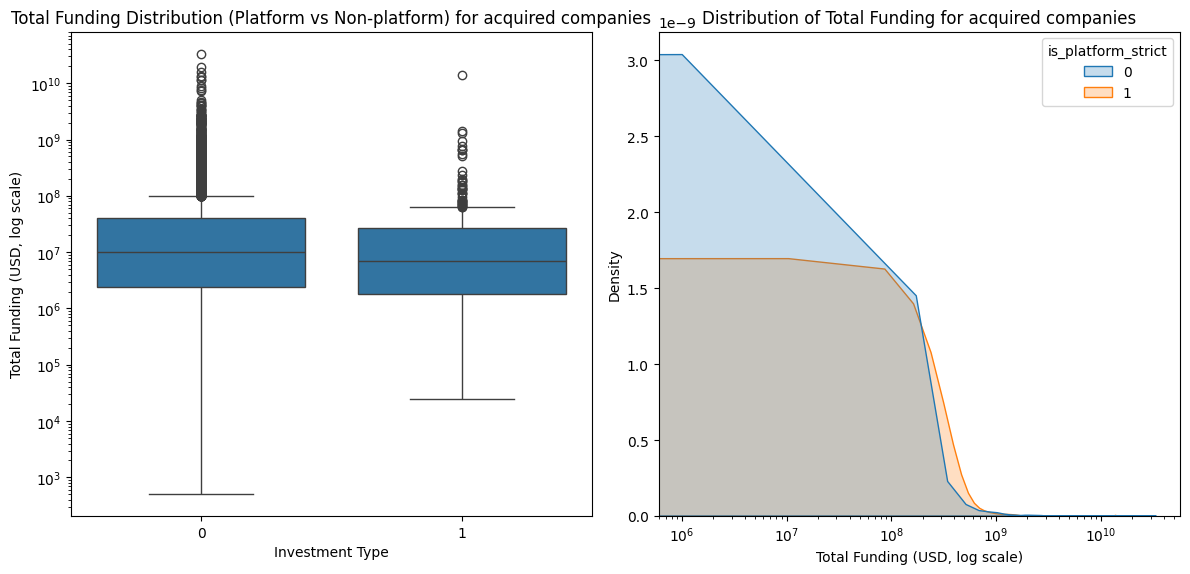

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Total Funding
# ---------------------------------------------------
sns.boxplot(
    data=df_acquired,
    y='total_funding_usd',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Total Funding Distribution (Platform vs Non-platform) for acquired companies")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Total Funding (USD, log scale)")
axs[0].set_yscale("log")          # Funding is usually very skewed

# ---------------------------------------------------
# 2) KDE PLOT — Total Funding
# ---------------------------------------------------
sns.kdeplot(
    data=df_acquired,
    x='total_funding_usd',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Total Funding for acquired companies")
axs[1].set_xlabel("Total Funding (USD, log scale)")
axs[1].set_ylabel("Density")
axs[1].set_xscale("log")          # KDE also needs log-scale

# ---------------------------------------------------
plt.tight_layout()
plt.show()

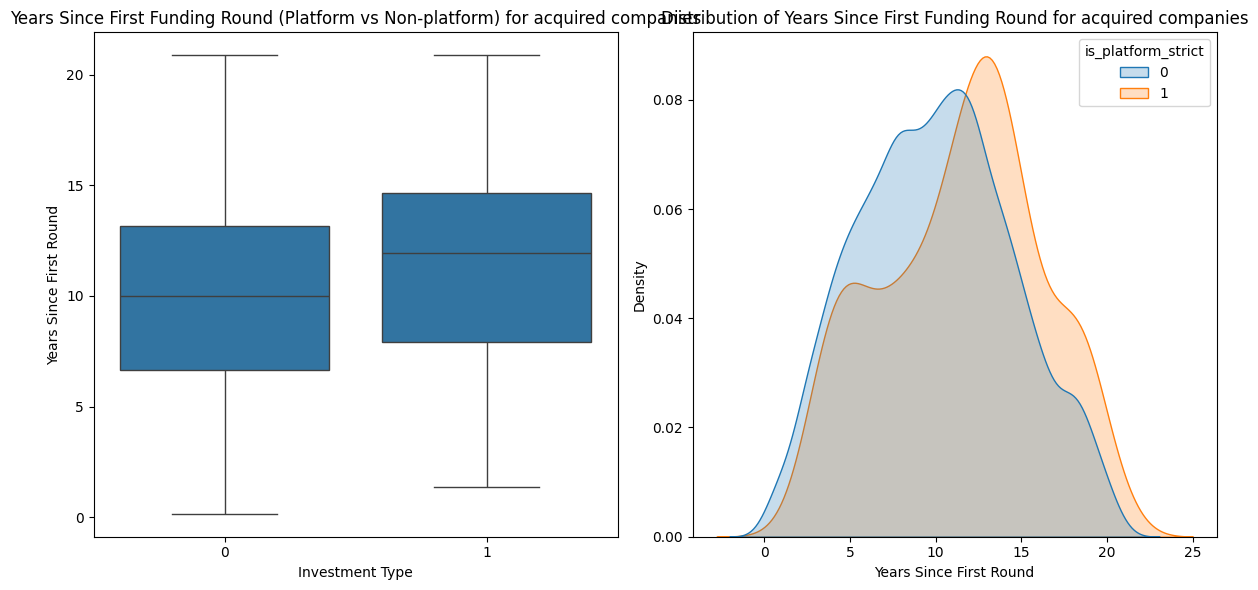

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Years Since First Round
# ---------------------------------------------------
sns.boxplot(
    data=df_acquired,
    y='years_since_first_round',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Years Since First Funding Round (Platform vs Non-platform) for acquired companies")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Years Since First Round")

# ---------------------------------------------------
# 2) KDE PLOT — Years Since First Round
# ---------------------------------------------------
sns.kdeplot(
    data=df_acquired,
    x='years_since_first_round',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Years Since First Funding Round for acquired companies")
axs[1].set_xlabel("Years Since First Round")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()